# Codeletion (1p/19q) selective-prediction bench: generalisation check for RQ2

Tests whether "predictive uncertainty beats OOD for selective prediction"
(the main bench's core methods finding) replicates on a second,
independently-labelled, glioma-defining target using the same locked
pipeline. Not a novel-codeletion-prediction paper; the contribution is the
generalisation check itself.

Cohort: EBRAINS (train, 5-fold CV) to TCGA (external eval), same
train/eval direction as the main IDH bench, restricted to ground-truth
IDH-mutant patients by construction (1p/19q is only clinically assessed in
IDH-mutant gliomas, see `scripts/build_1p19q_labels.py`). A secondary IPD
Brain arm uses a weaker Subtype-based codeletion proxy (not a genomic
assay), tiered by ATRX-IHC concordance (127/138 concordant, the confident
tier), reported separately, not blended into the primary TCGA/EBRAINS
finding. No age-equity arm was originally planned (worse power than IDH's
already-failed power audit), but the age-band split turns out to be
well-powered here specifically because codeletion's IDH-mutant-only
restriction skews the cohort younger than the full IDH population
(n=212/415 in the 20-39 TCGA band); see E3 below.

In [6]:
from __future__ import annotations

from pathlib import Path
from itertools import combinations
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal, fisher_exact, norm, rankdata
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    f1_score, brier_score_loss, confusion_matrix, roc_curve,
)

from IPython.display import display

warnings.filterwarnings("ignore")   # bootstrap loops on tiny subgroups trip harmless
                                     # RuntimeWarnings (empty means, etc.); silenced once, here.

RNG_SEED = 42

import hashlib

def stable_seed(*parts):
    """Deterministic substitute for Python's built-in hash() when deriving a
    per-subgroup bootstrap seed. hash() on str/tuple is salted per-process
    (PYTHONHASHSEED) by default, so two runs of this notebook would silently
    draw different bootstrap resamples for every subgroup-level analysis
    unless PYTHONHASHSEED is fixed externally; this keeps those resamples
    (and therefore every reported CI/q-value/MDE that depends on them)
    identical across machines and re-runs.
    """
    digest = hashlib.md5(repr(parts).encode()).hexdigest()
    return int(digest, 16) % 9999
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
print("Project root:", BASE)

OUT_DIR = BASE / "outputs/selective_prediction_bench_codel"
OUT_DIR.mkdir(parents=True, exist_ok=True)
MASTER_CSV = OUT_DIR / "master_patient_table.csv"

# Encoders
ABMIL_ENCODERS = ["uni2", "conch", "hoptimus"]   # encoders in the ABMIL predictor ensemble
OOD_ENCODERS   = ["uni2", "hoptimus"]            # encoders used for OOD signals
FOLDS = [0, 1, 2, 3, 4]
CLASS_NAMES = ("gbm", "astrocytoma", "oligodendroglioma")   # OOD density model classes
NUM_CLASSES = len(CLASS_NAMES)
ABMIL_N_CLASSES = 2                              # IDH wildtype / mutant

# OOD slide-level aggregations to precompute per encoder
OOD_AGGREGATIONS = ["topk", "attention", "mean"]

# Calibration centres (define the calibration split; no labels used for abstention)
CALIBRATION_SITES = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Fondazione-Besta",  # same institution, second spelling in tcga_clinical.csv --
                         # matters more here than in the main bench: only 416
                         # codel-eligible patients total, so this fix raises the
                         # calibration set from 49 to 65 (see plan doc for the count)
    "Mayo Clinic - Rochester",
}
TARGET_ABSTENTION_RATE = 0.20

# ABMIL checkpoints live at outputs/abmil/<model_name>/fold<k>/  -> attention source.
# Map each encoder to its ABMIL run-directory name (edit if your dirs differ,
# e.g. {"uni2": "uni2_abmil"}).
ABMIL_DIRS = {e: e for e in ABMIL_ENCODERS}
EXTRACT_ATTENTION = True   # False -> skip attention-weighted OOD strategies cleanly

# Canonical metadata source columns (from your clinical merge)
SITE_COL   = "tissue_source_site.name"
RACE_COL   = "demographic.race"
SEX_COL    = "demographic.gender"
TUMOUR_COL = "tumour_type_who2021"
IDH_COL    = "idh_status"
print("Config loaded.")


Project root: /cs/student/project_msc/2025/aibh/mpapageo
Config loaded.


## Part A: build the codel master table (TCGA eval cohort)

Reuses cached data throughout, no new inference beyond the two OOD scoring
scripts already run (`codel_ood_infer.py`, both encoders, both datasets).
`load_abmil_ensemble()` is the main bench's own function, pointed at the
codel embeddings tree instead of the IDH one; the
MC-dropout/deep-ensemble/Laplace loading cells below are copied verbatim
(already computed for codel by the existing `*_infer_codel.py` scripts).
The OOD merge is custom: `topk`/`mean` are pulled from the main bench's
own master table filtered to the 416 codel patients (verified identical
to a from-scratch codel-specific run, since the flow score doesn't depend
on which classifier's checkpoint is used for attention), and only
`attention` comes from the codel-specific `codel_ood_infer.py` run
(attention genuinely differs, since it reflects the codel classifier's
own saliency, not the IDH classifier's).

In [7]:
import numpy as np
import pandas as pd


def binary_entropy(p, eps=1e-10):
    """
    Binary entropy for mutant probabilities.

    Accepts scalars or arrays and returns values with the same shape.
    Natural logarithms are used, so entropy is measured in nats.
    """
    p = np.asarray(p, dtype=float)
    p = np.clip(p, eps, 1.0 - eps)

    return -(
        p * np.log(p)
        + (1.0 - p) * np.log(1.0 - p)
    )


def predictive_entropy_from_two_class_probs(probs, eps=1e-10):
    """
    Entropy of two-class probability vectors with shape (n, 2).
    """
    probs = np.asarray(probs, dtype=float)
    probs = np.clip(probs, eps, 1.0 - eps)

    return -np.sum(
        probs * np.log(probs),
        axis=1,
    )


def load_abmil_ensemble():
    """
    Load per-encoder, per-fold ABMIL predictions and derive patient-level
    uncertainty signals.

    Decomposition (all in nats):

        ensemble_entropy = aleatoric + total_mi

    where aleatoric is the mean entropy of the individual encoder-fold
    members and total_mi is their disagreement (mutual information).
    With balanced folds per encoder this further decomposes as

        total_mi = between_encoder_mi + mean_within_encoder_mi

    The same identity holds per encoder:

        entropy_<enc> = aleatoric_<enc> + within_encoder_mi_<enc>

    Epistemic uncertainty here reflects fold resampling and encoder choice
    only; architecture, hyperparameters and training recipe are fixed
    across members.
    """
    frames = []

    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            path = (
                BASE
                / "outputs/embeddings_codel/tcga"
                / enc
                / f"fold{fold}.npz"
            )

            if not path.exists():
                print("WARNING missing", path)
                continue

            d = np.load(path, allow_pickle=True)

            frames.append(
                pd.DataFrame({
                    "patient": d["patients"].astype(str),
                    "encoder": enc,
                    "fold": fold,
                    "prob_wt": d["probs"][:, 0],
                    "prob_mutant": d["probs"][:, 1],
                    "label": d["labels"].astype(int),
                })
            )

    if not frames:
        raise FileNotFoundError(
            "No ABMIL prediction (.npz) files found."
        )

    allp = pd.concat(
        frames,
        ignore_index=True,
    )

    inconsistent_labels = (
        allp.groupby("patient")["label"].nunique()
        > 1
    )

    if inconsistent_labels.any():
        bad_patients = inconsistent_labels[
            inconsistent_labels
        ].index.tolist()

        raise RuntimeError(
            "Inconsistent labels across ABMIL files for "
            f"{len(bad_patients)} patients."
        )

    # ------------------------------------------------------------
    # 1. Overall prediction and entropy across all encoder-fold models
    # ------------------------------------------------------------

    overall = (
        allp.groupby("patient")
        .agg(
            prob_wt=("prob_wt", "mean"),
            prob_mutant=("prob_mutant", "mean"),
            label=("label", "first"),
            n_abmil_rows=("prob_mutant", "size"),
            n_encoders=("encoder", "nunique"),
        )
        .reset_index()
    )

    overall["ensemble_entropy"] = (
        predictive_entropy_from_two_class_probs(
            overall[
                ["prob_wt", "prob_mutant"]
            ].to_numpy()
        )
    )

    # ------------------------------------------------------------
    # 2. Aleatoric component and total disagreement
    # ------------------------------------------------------------

    mean_member_entropy = (
        allp.assign(
            member_entropy=binary_entropy(
                allp["prob_mutant"].to_numpy()
            )
        )
        .groupby("patient")["member_entropy"]
        .mean()
        .rename("mean_member_entropy")
        .reset_index()
    )

    overall = overall.merge(
        mean_member_entropy,
        on="patient",
        how="left",
    )

    # Aleatoric uncertainty: expected entropy of the individual members.
    overall["aleatoric"] = overall["mean_member_entropy"]

    raw_total_mi = (
        overall["ensemble_entropy"]
        - overall["mean_member_entropy"]
    )

    # Flag rows where the raw value was negative before clipping, since
    # for those rows aleatoric != ensemble_entropy - total_mi.
    overall["total_mi_clipped"] = raw_total_mi < 0

    overall["total_mi"] = raw_total_mi.clip(lower=0.0)

    # ------------------------------------------------------------
    # 3. Encoder-level mean probabilities
    # ------------------------------------------------------------

    encoder_means_long = (
        allp.groupby(
            ["patient", "encoder"],
            as_index=False,
        )
        .agg(
            encoder_prob_mutant=("prob_mutant", "mean"),
            n_folds=("fold", "nunique"),
        )
    )

    encoder_means_wide = (
        encoder_means_long
        .pivot(
            index="patient",
            columns="encoder",
            values="encoder_prob_mutant",
        )
        .add_prefix("prob_mutant_")
        .reset_index()
    )

    # ------------------------------------------------------------
    # 4. Within-encoder fold disagreement
    # ------------------------------------------------------------

    within_encoder_rows = []

    for (
        patient,
        encoder,
    ), group in allp.groupby(
        ["patient", "encoder"],
        sort=False,
    ):
        fold_probs = (
            group["prob_mutant"]
            .to_numpy(dtype=float)
        )

        mean_prob = np.mean(fold_probs)

        predictive_entropy = binary_entropy(
            mean_prob
        )

        expected_entropy = np.mean(
            binary_entropy(fold_probs)
        )

        within_mi = max(
            float(
                predictive_entropy
                - expected_entropy
            ),
            0.0,
        )

        within_encoder_rows.append({
            "patient": patient,
            "encoder": encoder,
            "within_encoder_entropy":
                float(predictive_entropy),
            "within_encoder_aleatoric":
                float(expected_entropy),
            "within_encoder_mi": within_mi,
            "fold_probability_sd":
                float(np.std(fold_probs, ddof=0)),
            "fold_probability_range":
                float(
                    np.max(fold_probs)
                    - np.min(fold_probs)
                ),
            "n_folds": len(fold_probs),
        })

    within_encoder = pd.DataFrame(
        within_encoder_rows
    )

    def _pivot(column, prefix):
        return (
            within_encoder
            .pivot(
                index="patient",
                columns="encoder",
                values=column,
            )
            .add_prefix(prefix)
            .reset_index()
        )

    within_mi_wide = _pivot(
        "within_encoder_mi",
        "within_encoder_mi_",
    )

    within_sd_wide = _pivot(
        "fold_probability_sd",
        "fold_probability_sd_",
    )

    within_entropy_wide = _pivot(
        "within_encoder_entropy",
        "entropy_",
    )

    within_aleatoric_wide = _pivot(
        "within_encoder_aleatoric",
        "aleatoric_",
    )

    mean_within_encoder = (
        within_encoder
        .groupby("patient")
        .agg(
            mean_within_encoder_mi=(
                "within_encoder_mi",
                "mean",
            ),
            max_within_encoder_mi=(
                "within_encoder_mi",
                "max",
            ),
            mean_fold_probability_sd=(
                "fold_probability_sd",
                "mean",
            ),
            max_fold_probability_sd=(
                "fold_probability_sd",
                "max",
            ),
        )
        .reset_index()
    )

    # ------------------------------------------------------------
    # 5. Between-encoder disagreement
    # ------------------------------------------------------------

    between_encoder_rows = []

    for patient, group in encoder_means_long.groupby(
        "patient",
        sort=False,
    ):
        encoder_probs = (
            group["encoder_prob_mutant"]
            .dropna()
            .to_numpy(dtype=float)
        )

        if len(encoder_probs) == 0:
            between_encoder_rows.append({
                "patient": patient,
                "between_encoder_entropy": np.nan,
                "between_encoder_mi": np.nan,
                "encoder_probability_sd": np.nan,
                "encoder_probability_range": np.nan,
                "n_available_encoders": 0,
            })
            continue

        mean_prob = np.mean(encoder_probs)

        between_entropy = binary_entropy(
            mean_prob
        )

        mean_encoder_entropy = np.mean(
            binary_entropy(encoder_probs)
        )

        between_mi = max(
            float(
                between_entropy
                - mean_encoder_entropy
            ),
            0.0,
        )

        between_encoder_rows.append({
            "patient": patient,
            "between_encoder_entropy":
                float(between_entropy),
            "between_encoder_mi":
                between_mi,
            "encoder_probability_sd":
                float(
                    np.std(
                        encoder_probs,
                        ddof=0,
                    )
                ),
            "encoder_probability_range":
                float(
                    np.max(encoder_probs)
                    - np.min(encoder_probs)
                ),
            "n_available_encoders":
                len(encoder_probs),
        })

    between_encoder = pd.DataFrame(
        between_encoder_rows
    )

    # ------------------------------------------------------------
    # 6. Merge patient-level outputs
    # ------------------------------------------------------------

    output = (
        overall
        .merge(
            encoder_means_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_mi_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_sd_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_entropy_wide,
            on="patient",
            how="left",
        )
        .merge(
            within_aleatoric_wide,
            on="patient",
            how="left",
        )
        .merge(
            mean_within_encoder,
            on="patient",
            how="left",
        )
        .merge(
            between_encoder,
            on="patient",
            how="left",
        )
    )

    # ------------------------------------------------------------
    # 7. Consistency checks on the decomposition
    # ------------------------------------------------------------

    alea_dev = (
        (output["ensemble_entropy"] - output["total_mi"])
        - output["aleatoric"]
    ).abs()

    decomp_dev = (
        output["total_mi"]
        - (
            output["between_encoder_mi"]
            + output["mean_within_encoder_mi"]
        )
    ).abs()

    print(
        "decomposition checks | "
        f"aleatoric max dev {alea_dev.max():.2e} "
        f"(clipped rows {int(output['total_mi_clipped'].sum())}) | "
        f"total vs between+within max dev {decomp_dev.max():.2e}"
    )
    print(
        "members per patient  "
        f"{output['n_abmil_rows'].value_counts().to_dict()} | "
        "encoders per patient "
        f"{output['n_encoders'].value_counts().to_dict()}"
    )

    return output, allp, within_encoder

In [8]:
# ------------------------------------------------------------------
# A.2/A.4: OOD merge (topk/mean from the main IDH bench, filtered to
# codel patients -- classifier-independent, verified identical; attention
# from codel_ood_infer.py -- codel-classifier-specific, genuinely different)
# plus clinical metadata merge, assembling the codel master table.
# ------------------------------------------------------------------
abmil, abmil_member_predictions, within_encoder_results = load_abmil_ensemble()

idh_master = pd.read_csv(BASE / "outputs/selective_prediction_bench/master_patient_table.csv")
idh_master["patient"] = idh_master["patient"].astype(str)
codel_patients = set(abmil["patient"])

ood_frames = []
for enc in OOD_ENCODERS:
    topk_mean = idh_master.loc[idh_master["patient"].isin(codel_patients),
                                ["patient", f"ood_topk_{enc}", f"ood_mean_{enc}"]]
    attn = pd.read_csv(BASE / f"outputs/ood/codel_tcga/{enc}_summary.csv")
    attn["patient"] = attn["patient"].astype(str)
    attn = attn[["patient", f"ood_attention_{enc}"]]
    merged = topk_mean.merge(attn, on="patient", how="outer")
    ood_frames.append(merged)
ood = ood_frames[0]
for f in ood_frames[1:]:
    ood = ood.merge(f, on="patient", how="outer")
print("OOD columns:", [c for c in ood.columns if c != "patient"])
print("n missing per OOD column:", ood.drop(columns="patient").isna().sum().to_dict())

slide = pd.read_csv(BASE / "data/processed/slide_table_tcga_uni2.csv")
clin  = pd.read_csv(BASE / "data/raw/tcga/clinical/tcga_clinical.csv")
slide["PATIENT"] = slide["PATIENT"].astype(str)
clin["submitter_id"] = clin["submitter_id"].astype(str)
slide = slide.merge(clin, left_on="PATIENT", right_on="submitter_id",
                    how="left", validate="many_to_one")
meta = slide.sort_values("PATIENT").drop_duplicates("PATIENT")

master = (abmil.merge(ood, on="patient", how="inner")
               .merge(meta, left_on="patient", right_on="PATIENT",
                      how="left", validate="one_to_one"))
master.to_csv(MASTER_CSV, index=False)
print("Saved", MASTER_CSV, master.shape)


decomposition checks | aleatoric max dev 2.78e-17 (clipped rows 0) | total vs between+within max dev 1.70e-07
members per patient  {15: 416} | encoders per patient {3: 416}
OOD columns: ['ood_topk_uni2', 'ood_mean_uni2', 'ood_attention_uni2', 'ood_topk_hoptimus', 'ood_mean_hoptimus', 'ood_attention_hoptimus']
n missing per OOD column: {'ood_topk_uni2': 0, 'ood_mean_uni2': 0, 'ood_attention_uni2': 0, 'ood_topk_hoptimus': 0, 'ood_mean_hoptimus': 0, 'ood_attention_hoptimus': 0}
Saved /cs/student/project_msc/2025/aibh/mpapageo/outputs/selective_prediction_bench_codel/master_patient_table.csv (416, 121)


### A.6: MC-dropout uncertainty

`mc_dropout_infer.py` has already run 500 dropout passes per patient for
every (encoder, fold) on TCGA and cached the same BALD decomposition used
throughout this project: `predictive_entropy = aleatoric + epistemic_mi`.

Loads those cached per-(encoder, fold) summaries, averages each encoder's
5 already-independently-trained fold models' MC-dropout stats into one
per-encoder signal, and separately across encoders into one pooled signal
(matching `ensemble_entropy`'s granularity). Averaging the
already-decomposed per-fold values, rather than pooling raw dropout
probabilities across folds first, keeps this scoped to within-model
parameter uncertainty only, so it isn't conflated with the cross-fold
disagreement `within_encoder_mi`/`total_mi` already measures.

In [ ]:
MC_DROPOUT_COLS_EXPECTED = (
    [f"mc_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"mc_epistemic_mi_{e}" for e in ABMIL_ENCODERS]
    + ["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"]
)

if all(c in master.columns for c in MC_DROPOUT_COLS_EXPECTED):
    print("MC-dropout columns already present in the cached master table; skipping recomputation.")
else:
    print("MC-dropout columns missing; loading from outputs/mc_dropout_codel/tcga/...")

    mc_frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            p = BASE / f"outputs/mc_dropout_codel/tcga/{enc}/fold{fold}_summary.csv"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            fdf = pd.read_csv(p)
            fdf["encoder"] = enc
            mc_frames.append(fdf)
    mc_all = pd.concat(mc_frames, ignore_index=True)
    mc_all["patient"] = mc_all["patient"].astype(str)

    # Per-encoder mc_predictive_entropy_<enc>: same Jensen's-inequality issue as
    # the pooled step below, one level down -- binary_entropy is concave, so
    # averaging 5 already-computed fold-level entropies underestimates the true
    # entropy of that encoder's 5-fold mean probability. Recomputed from each
    # encoder's own grand-mean probability across its 5 folds instead.
    per_enc_prob = (mc_all.groupby(["patient", "encoder"])["mean_prob_mutant"]
                     .mean().reset_index())
    per_enc_prob["mc_predictive_entropy"] = binary_entropy(
        per_enc_prob["mean_prob_mutant"].to_numpy()
    )
    per_enc_linear = (mc_all.groupby(["patient", "encoder"])
                       .agg(mc_aleatoric=("aleatoric", "mean"),
                            mc_epistemic_mi=("epistemic_mi", "mean"))
                       .reset_index())
    per_enc = per_enc_prob[["patient", "encoder", "mc_predictive_entropy"]].merge(
        per_enc_linear, on=["patient", "encoder"]
    )

    wide = per_enc.pivot(index="patient", columns="encoder",
                          values=["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    linear_pooled = (per_enc.groupby("patient")
                      .agg(mc_aleatoric=("mc_aleatoric", "mean"),
                           mc_epistemic_mi=("mc_epistemic_mi", "mean"))
                      .reset_index())

    grand_mean_prob = mc_all.groupby("patient")["mean_prob_mutant"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "mc_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
    })

    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")

    mc_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("mc_")],
                          errors="ignore")
    master = master.merge(mc_cols, on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_mc_dropout.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended MC-dropout columns:", [c for c in master.columns if c.startswith("mc_")])


MC-dropout columns missing; loading from outputs/mc_dropout_codel/tcga/...
appended MC-dropout columns: ['mc_predictive_entropy_conch', 'mc_predictive_entropy_hoptimus', 'mc_predictive_entropy_uni2', 'mc_aleatoric_conch', 'mc_aleatoric_hoptimus', 'mc_aleatoric_uni2', 'mc_epistemic_mi_conch', 'mc_epistemic_mi_hoptimus', 'mc_epistemic_mi_uni2', 'mc_aleatoric', 'mc_epistemic_mi', 'mc_predictive_entropy']


### A.7: Deep-ensemble uncertainty

`train_abmil_deep_ensemble.py` trained 8 independently-initialised ABMIL
models (`init_seed` 43-50) per (encoder, fold), on the exact same EBRAINS
train/val partition as the locked `outputs/abmil/` checkpoints, so
disagreement across `init_seed` is weight-init/training-randomness
epistemic uncertainty, a third axis alongside the encoder and fold axes
`load_abmil_ensemble()` already decomposes. `deep_ensemble_infer.py` has
already scored all 8 members on TCGA for every (encoder, fold).

For each encoder, computes the same BALD decomposition within each fold
across its 8 init-seed members, then averages that within-fold init-seed
MI across the 5 folds, the new epistemic term, holding data/fold fixed
and varying only init. This is purely additive: the existing
`within_encoder_mi`/`between_encoder_mi` (fold-level disagreement of the
single locked `best.ckpt` per fold) are untouched.

In [ ]:
DEEP_ENSEMBLE_COLS_EXPECTED = (
    [f"de_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"de_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"de_within_fold_mi_{e}" for e in ABMIL_ENCODERS]
    + ["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"]
)

if all(c in master.columns for c in DEEP_ENSEMBLE_COLS_EXPECTED):
    print("Deep-ensemble columns already present in the cached master table; skipping recomputation.")
else:
    print("Deep-ensemble columns missing; loading from outputs/deep_ensemble_codel/tcga/...")

    def _de_binary_entropy(p, eps=1e-10):
        p = np.clip(np.asarray(p, dtype=float), eps, 1.0 - eps)
        return -(p * np.log(p) + (1.0 - p) * np.log(1.0 - p))

    de_per_enc_frames = []
    de_consistency = []
    all_fold_rows = []
    for enc in ABMIL_ENCODERS:
        fold_rows = []
        for fold in FOLDS:
            p = BASE / f"outputs/deep_ensemble_codel/tcga/{enc}/fold{fold}.npz"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            d = np.load(p, allow_pickle=True)
            patients = d["patients"].astype(str)
            member_probs = d["member_probs"]              # [N, K] init-seed members
            fold_mean = member_probs.mean(axis=1)
            fold_pred_entropy = _de_binary_entropy(fold_mean)
            fold_aleatoric = _de_binary_entropy(member_probs).mean(axis=1)
            fold_mi = np.clip(fold_pred_entropy - fold_aleatoric, 0.0, None)
            df = pd.DataFrame({
                "patient": patients, "fold": fold,
                "fold_mean_prob": fold_mean,
                "fold_pred_entropy": fold_pred_entropy,
                "fold_aleatoric": fold_aleatoric,
                "fold_within_fold_mi": fold_mi,
            })
            fold_rows.append(df)
            all_fold_rows.append(df.assign(encoder=enc))
        allf = pd.concat(fold_rows, ignore_index=True)

        # de_predictive_entropy_<enc>: same Jensen's-inequality issue fixed for
        # mc_dropout/laplace applies here too -- recompute from this encoder's
        # own grand-mean probability across its 5 folds, not the mean of 5
        # already-computed fold-level entropies.
        enc_grand_mean_prob = allf.groupby("patient")["fold_mean_prob"].mean()
        per_patient = allf.groupby("patient").agg(
            de_aleatoric=("fold_aleatoric", "mean"),
            de_within_fold_mi=("fold_within_fold_mi", "mean"),
        ).reset_index()
        per_patient["de_predictive_entropy"] = per_patient["patient"].map(
            pd.Series(_de_binary_entropy(enc_grand_mean_prob.to_numpy()),
                      index=enc_grand_mean_prob.index)
        )
        per_patient["encoder"] = enc

        grand = allf.groupby("patient").agg(
            grand_mean_prob=("fold_mean_prob", "mean"),
            mean_fold_entropy=("fold_pred_entropy", "mean"),
        )
        between_fold_mi = np.clip(
            _de_binary_entropy(grand["grand_mean_prob"]) - grand["mean_fold_entropy"], 0.0, None
        )
        total_mi_check = (
            between_fold_mi.to_numpy()
            + per_patient.set_index("patient")["de_within_fold_mi"].reindex(grand.index).to_numpy()
        )
        de_consistency.append((enc, float(total_mi_check.max()), float(total_mi_check.min())))

        de_per_enc_frames.append(per_patient)

    de_all = pd.concat(de_per_enc_frames, ignore_index=True)
    print("deep-ensemble between+within MI range per encoder (sanity only, not used downstream):",
          de_consistency)

    wide = de_all.pivot(index="patient", columns="encoder",
                         values=["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    linear_pooled = (de_all.groupby("patient")
                      .agg(de_aleatoric=("de_aleatoric", "mean"),
                           de_within_fold_mi=("de_within_fold_mi", "mean"))
                      .reset_index())

    all_fold_df = pd.concat(all_fold_rows, ignore_index=True)
    grand_mean_prob = all_fold_df.groupby("patient")["fold_mean_prob"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "de_predictive_entropy": _de_binary_entropy(grand_mean_prob.to_numpy()),
    })

    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")

    de_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("de_")],
                          errors="ignore")
    master = master.merge(de_cols, on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_deep_ensemble.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended deep-ensemble columns:", [c for c in master.columns if c.startswith("de_")])


Deep-ensemble columns missing; loading from outputs/deep_ensemble_codel/tcga/...
deep-ensemble between+within MI range per encoder (sanity only, not used downstream): [('uni2', 0.25984717061396734, 0.0007116035570244835), ('conch', 0.13956164075229388, 0.016640965890959127), ('hoptimus', 0.3449072612890797, 0.0017531713618939332)]
appended deep-ensemble columns: ['de_predictive_entropy_conch', 'de_predictive_entropy_hoptimus', 'de_predictive_entropy_uni2', 'de_aleatoric_conch', 'de_aleatoric_hoptimus', 'de_aleatoric_uni2', 'de_within_fold_mi_conch', 'de_within_fold_mi_hoptimus', 'de_within_fold_mi_uni2', 'de_aleatoric', 'de_within_fold_mi', 'de_predictive_entropy']


### A.8: Last-layer Laplace approximation

A third, mechanistically distinct way to estimate epistemic uncertainty:
instead of resampling activations (MC-dropout) or disagreement across
independently-trained models (deep ensemble), Laplace places a Gaussian
posterior directly over the already-trained classifier head's weights,
fit from the curvature of the training loss around the existing MAP
solution. No retraining, and no feature-space density model at all.

`laplace_infer.py` already fit last-layer Laplace per (encoder, fold), on
the same EBRAINS train/val split ABMIL itself was trained on, then scored
all TCGA patients with 200 posterior-predictive weight samples. Loads
those cached summaries and averages each encoder's 5 already-fit folds
into one per-encoder signal, and separately across encoders into one
pooled signal, the same averaging convention used for MC-dropout.

In [ ]:
LAPLACE_COLS_EXPECTED = (
    [f"laplace_predictive_entropy_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_aleatoric_{e}" for e in ABMIL_ENCODERS]
    + [f"laplace_epistemic_mi_{e}" for e in ABMIL_ENCODERS]
    + ["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"]
)

if all(c in master.columns for c in LAPLACE_COLS_EXPECTED):
    print("Laplace columns already present in the cached master table; skipping recomputation.")
else:
    print("Laplace columns missing; loading from outputs/laplace_codel/tcga/...")

    laplace_frames = []
    for enc in ABMIL_ENCODERS:
        for fold in FOLDS:
            p = BASE / f"outputs/laplace_codel/tcga/{enc}/fold{fold}_summary.csv"
            if not p.exists():
                print(f"  WARNING missing {p}"); continue
            fdf = pd.read_csv(p)
            fdf["encoder"] = enc
            laplace_frames.append(fdf)
    laplace_all = pd.concat(laplace_frames, ignore_index=True)
    laplace_all["patient"] = laplace_all["patient"].astype(str)

    # Per-encoder laplace_predictive_entropy_<enc>: same Jensen's-inequality issue
    # as mc_predictive_entropy_<enc> - recomputed from each encoder's own
    # grand-mean probability across its 5 folds, not averaged from 5 already-
    # computed fold-level entropies.
    per_enc_prob = (laplace_all.groupby(["patient", "encoder"])["mean_prob_mutant"]
                     .mean().reset_index())
    per_enc_prob["laplace_predictive_entropy"] = binary_entropy(
        per_enc_prob["mean_prob_mutant"].to_numpy()
    )
    per_enc_linear = (laplace_all.groupby(["patient", "encoder"])
                       .agg(laplace_aleatoric=("aleatoric", "mean"),
                            laplace_epistemic_mi=("epistemic_mi", "mean"))
                       .reset_index())
    per_enc = per_enc_prob[["patient", "encoder", "laplace_predictive_entropy"]].merge(
        per_enc_linear, on=["patient", "encoder"]
    )

    wide = per_enc.pivot(index="patient", columns="encoder",
                          values=["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"])
    wide.columns = [f"{a}_{b}" for a, b in wide.columns]
    wide = wide.reset_index()

    linear_pooled = (per_enc.groupby("patient")
                      .agg(laplace_aleatoric=("laplace_aleatoric", "mean"),
                           laplace_epistemic_mi=("laplace_epistemic_mi", "mean"))
                      .reset_index())

    grand_mean_prob = laplace_all.groupby("patient")["mean_prob_mutant"].mean()
    grand_pooled_entropy = pd.DataFrame({
        "patient": grand_mean_prob.index,
        "laplace_predictive_entropy": binary_entropy(grand_mean_prob.to_numpy()),
    })

    pooled = linear_pooled.merge(grand_pooled_entropy, on="patient", how="left")

    laplace_cols = wide.merge(pooled, on="patient", how="outer")

    master["patient"] = master["patient"].astype(str)
    master = master.drop(columns=[c for c in master.columns if c.startswith("laplace_")],
                          errors="ignore")
    master = master.merge(laplace_cols, on="patient", how="left")

    backup = MASTER_CSV.with_suffix(".pre_laplace.csv")
    if not backup.exists():
        pd.read_csv(MASTER_CSV).to_csv(backup, index=False)
    master.to_csv(MASTER_CSV, index=False)
    print("appended Laplace columns:", [c for c in master.columns if c.startswith("laplace_")])


Laplace columns missing; loading from outputs/laplace_codel/tcga/...


appended Laplace columns: ['laplace_predictive_entropy_conch', 'laplace_predictive_entropy_hoptimus', 'laplace_predictive_entropy_uni2', 'laplace_aleatoric_conch', 'laplace_aleatoric_hoptimus', 'laplace_aleatoric_uni2', 'laplace_epistemic_mi_conch', 'laplace_epistemic_mi_hoptimus', 'laplace_epistemic_mi_uni2', 'laplace_aleatoric', 'laplace_epistemic_mi', 'laplace_predictive_entropy']


## Part B: canonicalise metadata, derive groups, split calibration/eval

Maps clinical columns to canonical names, derives an age band and white
vs. non-white race (the full breakdown is kept too), then drops rows
missing any signal used by any strategy so all strategies are compared on
an identical cohort.

(`master` was already loaded and previewed in Part A, see its `.head()`
above.)

Every downstream analysis needs the same handful of canonical columns
(site, race, sex, age band, calibration/eval split); deriving them once
here, with explicit fallbacks when a column is missing, avoids five
slightly different versions of "what site is this patient from" appearing
later.

Canonicalises the clinical metadata columns into `site`,
`race_full`/`race_binary`, `sex`, `tumour_type`, `age`/`age_band`;
collects which uncertainty signals are usable; drops rows missing the
bare minimum needed by every strategy; and splits the cohort into the
calibration sites (used only to fit thresholds) and everything else
(evaluation).

In [12]:
def first_present(df, candidates):
    """Return the first candidate column present in df."""
    return next(
        (column for column in candidates if column in df.columns),
        None,
    )


def column_or_default(df, column, default):
    """
    Return an existing column or a same-length Series containing a default.

    Unlike df.get(column, default), this always returns a Series and therefore
    safely supports methods such as .astype().
    """
    if column in df.columns:
        return df[column]

    return pd.Series(
        default,
        index=df.index,
        dtype="object",
    )


# ------------------------------------------------------------------
# Demographic and clinical variables
# ------------------------------------------------------------------

age_src = first_present(
    master,
    [
        "age",
        "age_at_index",
        "demographic.age_at_index",
        "diagnoses.age_at_diagnosis",
    ],
)

if age_src is None:
    master["age"] = np.nan
else:
    master["age"] = pd.to_numeric(
        master[age_src],
        errors="coerce",
    )

    # TCGA age at diagnosis may be stored in days.
    if (
        age_src == "diagnoses.age_at_diagnosis"
        and master["age"].max(skipna=True) > 200
    ):
        master["age"] = master["age"] / 365.25


master["site"] = (
    column_or_default(master, SITE_COL, "Unknown")
    .fillna("Unknown")
    .astype(str)
    .str.strip()
)

master["race_full"] = (
    column_or_default(master, RACE_COL, "not reported")
    .fillna("not reported")
    .astype(str)
    .str.strip()
    .str.lower()
)

master["sex"] = (
    column_or_default(master, SEX_COL, "not reported")
    .fillna("not reported")
    .astype(str)
    .str.strip()
    .str.lower()
)

master["tumour_type"] = (
    column_or_default(master, TUMOUR_COL, "unknown")
    .fillna("unknown")
    .astype(str)
    .str.strip()
    .str.lower()
)


def to_race_binary(value):
    value = str(value).strip().lower()

    if value in {
        "",
        "nan",
        "none",
        "not reported",
        "unknown",
        "not available",
    }:
        return np.nan

    return "white" if value == "white" else "non-white"


master["race_binary"] = master["race_full"].map(
    to_race_binary
)

master["age_band"] = pd.cut(
    master["age"],
    bins=[0, 20, 40, 55, 70, np.inf],
    labels=[
        "<20",
        "20-39",
        "40-54",
        "55-69",
        "70+",
    ],
    right=False,
)


# ------------------------------------------------------------------
# Uncertainty signals
# ------------------------------------------------------------------

PREDICTIVE_SIGNAL_COLS = [
    "ensemble_entropy",
    "total_mi",
    "mean_within_encoder_mi",
    "between_encoder_mi",
]

OOD_SIGNAL_COLS = [
    f"ood_{prefix}{aggregation}_{encoder}"
    for prefix in ("", "maha_")
    for aggregation in OOD_AGGREGATIONS
    for encoder in OOD_ENCODERS
]


# Predictive uncertainty columns are expected and should not disappear
# silently because of an outdated cached master table.
missing_predictive_signals = [
    column
    for column in PREDICTIVE_SIGNAL_COLS
    if column not in master.columns
]

if missing_predictive_signals:
    raise KeyError(
        "The master table is missing required predictive uncertainty "
        f"columns: {missing_predictive_signals}"
    )


# OOD columns are included when present.
available_ood_signals = [
    column
    for column in OOD_SIGNAL_COLS
    if column in master.columns
]

SIGNAL_COLS = (
    PREDICTIVE_SIGNAL_COLS
    + available_ood_signals
)

usable_signals = [
    column
    for column in SIGNAL_COLS
    if master[column].notna().any()
]

all_missing_signals = [
    column
    for column in SIGNAL_COLS
    if not master[column].notna().any()
]

if all_missing_signals:
    print(
        "Signals containing no finite observations:",
        all_missing_signals,
    )


# ------------------------------------------------------------------
# Base analysis cohort
# ------------------------------------------------------------------

# Only drop rows missing information required for every analysis.
# Do not require complete observations for every uncertainty signal here.
required_base_cols = [
    "label",
    "prob_mutant",
    "site",
]

before = len(master)

df = (
    master
    .dropna(subset=required_base_cols)
    .copy()
    .reset_index(drop=True)
)

df["label"] = pd.to_numeric(
    df["label"],
    errors="raise",
).astype(int)

df["prob_mutant"] = pd.to_numeric(
    df["prob_mutant"],
    errors="coerce",
)

# Remove any probabilities that became missing during numeric conversion.
df = (
    df
    .dropna(subset=["prob_mutant"])
    .reset_index(drop=True)
)

if not df["label"].isin([0, 1]).all():
    unexpected_labels = sorted(
        df.loc[
            ~df["label"].isin([0, 1]),
            "label",
        ].unique()
    )

    raise ValueError(
        "Label must be binary 0/1. "
        f"Unexpected values: {unexpected_labels}"
    )


# ------------------------------------------------------------------
# Calibration/evaluation split
# ------------------------------------------------------------------

cal_mask = df["site"].isin(CALIBRATION_SITES)

cal_df = (
    df.loc[cal_mask]
    .copy()
    .reset_index(drop=True)
)

eval_df = (
    df.loc[~cal_mask]
    .copy()
    .reset_index(drop=True)
)

assert not cal_df.empty, (
    "Calibration set is empty; check CALIBRATION_SITES against the "
    "values in master['site']."
)

assert not eval_df.empty, (
    "Evaluation set is empty; check CALIBRATION_SITES."
)


# ------------------------------------------------------------------
# Reporting and checks
# ------------------------------------------------------------------

print(
    f"Dropped {before - len(df)} rows missing required base variables; "
    f"cohort = {len(df)}"
)

print(
    f"Calibration {len(cal_df)} | evaluation {len(eval_df)}"
)

print("Predictive signals:", PREDICTIVE_SIGNAL_COLS)
print("Available OOD signals:", available_ood_signals)
print("Usable signals:", usable_signals)

print(
    "Calibration prevalence (mutant):",
    round(cal_df["label"].mean(), 3),
)

print(
    "Evaluation prevalence (mutant):",
    round(eval_df["label"].mean(), 3),
)

print("\nSignal availability:")
print(
    df[usable_signals]
    .notna()
    .agg(["sum", "mean"])
    .T
    .rename(
        columns={
            "sum": "n_available",
            "mean": "proportion_available",
        }
    )
)

Dropped 0 rows missing required base variables; cohort = 416
Calibration 66 | evaluation 350
Predictive signals: ['ensemble_entropy', 'total_mi', 'mean_within_encoder_mi', 'between_encoder_mi']
Available OOD signals: ['ood_topk_uni2', 'ood_topk_hoptimus', 'ood_attention_uni2', 'ood_attention_hoptimus', 'ood_mean_uni2', 'ood_mean_hoptimus']
Usable signals: ['ensemble_entropy', 'total_mi', 'mean_within_encoder_mi', 'between_encoder_mi', 'ood_topk_uni2', 'ood_topk_hoptimus', 'ood_attention_uni2', 'ood_attention_hoptimus', 'ood_mean_uni2', 'ood_mean_hoptimus']
Calibration prevalence (mutant): 0.47
Evaluation prevalence (mutant): 0.374

Signal availability:
                        n_available  proportion_available
ensemble_entropy              416.0                   1.0
total_mi                      416.0                   1.0
mean_within_encoder_mi        416.0                   1.0
between_encoder_mi            416.0                   1.0
ood_topk_uni2                 416.0              

## Part C: the strategy engine (verbatim from the main bench, target-agnostic)

In [13]:
def _standardize(df_, signals):
    X = df_[signals].to_numpy(float)
    mean = X.mean(0); scale = X.std(0); scale[scale == 0] = 1.0
    return mean, scale

def _group_matrix(df_, spec, mean, scale, signals):
    sidx = {s: i for i, s in enumerate(signals)}
    Xz = (df_[signals].to_numpy(float) - mean) / scale
    return np.column_stack([Xz[:, [sidx[s] for s in g]].mean(1) for g in spec["groups"]])

def fit_rule(cal, spec, target_rate, qgrid=None):
    signals = sorted({s for g in spec["groups"] for s in g})
    mean, scale = _standardize(cal, signals)
    G = _group_matrix(cal, spec, mean, scale, signals)
    combine = spec["combine"]
    qgrid = np.linspace(0.01, 0.999, 2000) if qgrid is None else qgrid
    best = None
    for q in qgrid:
        if combine in ("single", "mean_z"):
            comb = G.mean(1) if combine == "mean_z" else G[:, 0]
            tau = float(np.quantile(comb, q)); ab = comb >= tau
            thr = {"__combined__": tau}
        else:
            taus = [float(np.quantile(G[:, j], q)) for j in range(G.shape[1])]
            masks = [G[:, j] >= taus[j] for j in range(G.shape[1])]
            ab = (np.logical_or.reduce(masks) if combine == "or"
                  else np.logical_and.reduce(masks))
            thr = {f"g{j}": taus[j] for j in range(G.shape[1])}
        rate = ab.mean(); err = abs(rate - target_rate)
        if best is None or err < best["err"]:
            best = {"err": err, "q": float(q), "thr": thr, "rate": float(rate)}
    return {"spec": spec, "signals": signals, "mean": mean, "scale": scale,
            "combine": combine, "thresholds": best["thr"],
            "quantile": best["q"], "cal_rate": best["rate"]}

def apply_rule(df_, rule):
    spec, sig = rule["spec"], rule["signals"]
    G = _group_matrix(df_, spec, rule["mean"], rule["scale"], sig)
    combine = rule["combine"]
    if combine in ("single", "mean_z"):
        comb = G.mean(1) if combine == "mean_z" else G[:, 0]
        tau = rule["thresholds"]["__combined__"]; ab, risk = comb >= tau, comb - tau
    else:
        taus = [rule["thresholds"][f"g{j}"] for j in range(G.shape[1])]
        margins = [G[:, j] - taus[j] for j in range(G.shape[1])]
        masks = [G[:, j] >= taus[j] for j in range(G.shape[1])]
        if combine == "or":
            ab, risk = np.logical_or.reduce(masks), np.maximum.reduce(margins)
        else:
            ab, risk = np.logical_and.reduce(masks), np.minimum.reduce(margins)
    out = df_.copy(); out["abstained"] = ab; out["risk_score"] = risk
    return out

In [14]:
# --- define strategies (1-4) -----------------------------------------------------
def ood(agg, enc): return f"ood_{agg}_{enc}"
have = lambda c: c in df.columns and df[c].notna().any()

COMBO_OOD_AGG = "attention"   # OOD aggregation used inside ensemble+OOD combos ("topk" or "attention")

STRATEGIES = {}
STRATEGIES["ensemble_only"] = {"groups": [["ensemble_entropy"]], "combine": "single"}
STRATEGIES["mc_dropout_only"] = {"groups": [["mc_epistemic_mi"]], "combine": "single"}
STRATEGIES["deep_ensemble_only"] = {"groups": [["de_within_fold_mi"]], "combine": "single"}
STRATEGIES["laplace_only"] = {"groups": [["laplace_epistemic_mi"]], "combine": "single"}
for e in OOD_ENCODERS:                                   # (3) top-x% OOD per encoder, alone
    if have(ood("topk", e)):
        STRATEGIES[f"ood_topk_{e}"] = {"groups": [[ood("topk", e)]], "combine": "single"}
for e in OOD_ENCODERS:                                   # (2) attention-weighted per encoder, alone
    if have(ood("attention", e)):
        STRATEGIES[f"ood_attn_{e}"] = {"groups": [[ood("attention", e)]], "combine": "single"}

# (4a) ensemble entropy combined with EACH encoder's OOD separately (OR / AND / mean-of-z)
for e in OOD_ENCODERS:
    c = ood(COMBO_OOD_AGG, e)
    if not have(c):
        continue
    STRATEGIES[f"ens_OR_{e}"]    = {"groups": [["ensemble_entropy"], [c]], "combine": "or"}
    STRATEGIES[f"ens_AND_{e}"]   = {"groups": [["ensemble_entropy"], [c]], "combine": "and"}
    STRATEGIES[f"ens_MEANZ_{e}"] = {"groups": [["ensemble_entropy"], [c]], "combine": "mean_z"}

# (4b) ensemble entropy combined with ALL encoders' OOD pooled together
topk_ood = [ood("topk", e) for e in OOD_ENCODERS if have(ood("topk", e))]
if topk_ood:
    STRATEGIES["ood_topk_meanz"] = {"groups": [topk_ood], "combine": "mean_z"}
    STRATEGIES["ens_OR_ood"]     = {"groups": [["ensemble_entropy"], topk_ood], "combine": "or"}
    STRATEGIES["ens_AND_ood"]    = {"groups": [["ensemble_entropy"], topk_ood], "combine": "and"}
    STRATEGIES["ens_MEANZ_ood"]  = {"groups": [["ensemble_entropy"], *[[c] for c in topk_ood]],
                                    "combine": "mean_z"}
ood_attn = [ood("attention", e) for e in OOD_ENCODERS if have(ood("attention", e))]
if ood_attn:
    STRATEGIES["ood_attn_meanz"] = {"groups": [ood_attn], "combine": "mean_z"}
    STRATEGIES["ens_OR_ood_attn"]     = {"groups": [["ensemble_entropy"], ood_attn], "combine": "or"}
    STRATEGIES["ens_AND_ood_attn"]    = {"groups": [["ensemble_entropy"], ood_attn], "combine": "and"}
    STRATEGIES["ens_MEANZ_ood_attn"]  = {"groups": [["ensemble_entropy"], *[[c] for c in ood_attn]],
                                         "combine": "mean_z"}
print(f"{len(STRATEGIES)} strategies:")
for k, v in STRATEGIES.items():
    print(f"  {k:20s} combine={v['combine']:7s} groups={v['groups']}")

22 strategies:
  ensemble_only        combine=single  groups=[['ensemble_entropy']]
  mc_dropout_only      combine=single  groups=[['mc_epistemic_mi']]
  deep_ensemble_only   combine=single  groups=[['de_within_fold_mi']]
  laplace_only         combine=single  groups=[['laplace_epistemic_mi']]
  ood_topk_uni2        combine=single  groups=[['ood_topk_uni2']]
  ood_topk_hoptimus    combine=single  groups=[['ood_topk_hoptimus']]
  ood_attn_uni2        combine=single  groups=[['ood_attention_uni2']]
  ood_attn_hoptimus    combine=single  groups=[['ood_attention_hoptimus']]
  ens_OR_uni2          combine=or      groups=[['ensemble_entropy'], ['ood_attention_uni2']]
  ens_AND_uni2         combine=and     groups=[['ensemble_entropy'], ['ood_attention_uni2']]
  ens_MEANZ_uni2       combine=mean_z  groups=[['ensemble_entropy'], ['ood_attention_uni2']]
  ens_OR_hoptimus      combine=or      groups=[['ensemble_entropy'], ['ood_attention_hoptimus']]
  ens_AND_hoptimus     combine=and     groups=[

## Part D: metrics, bootstrap CIs, predictor thresholds (verbatim, target-agnostic)

In [ ]:
def expected_calibration_error(y, p, n_bins=10):
    # Vectorized (bincount) instead of a Python loop over bins -- same formula,
    # validated numerically identical against the original loop version (see
    # the main bench's own validate_fast_metrics.py check, ported here unchanged).
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    n = len(y)
    counts = np.bincount(idx, minlength=n_bins).astype(float)
    sum_y = np.bincount(idx, weights=y, minlength=n_bins)
    sum_p = np.bincount(idx, weights=p, minlength=n_bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        gap = np.abs(sum_y / counts - sum_p / counts)
    gap = np.nan_to_num(gap, nan=0.0)
    return float(np.sum(counts / n * gap))

def binary_metrics(y, p, thr):
    # Vectorized replacement for confusion_matrix/balanced_accuracy_score/
    # f1_score/brier_score_loss/roc_auc_score -- same validated fix as the
    # main bench's Part D. AUROC via the rank-sum/Mann-Whitney identity
    # (exact, matches roc_auc_score's tie handling via scipy's rankdata).
    y = np.asarray(y, int); p = np.asarray(p, float); yhat = (p >= thr).astype(int)
    n = len(y)
    out = {"n": n, "prevalence": float(y.mean()) if n else np.nan}
    n_pos = int(y.sum()); n_neg = n - n_pos
    if n_pos > 0 and n_neg > 0:
        ranks = rankdata(p)
        out["auroc"] = float((ranks[y == 1].sum() - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg))
        out["auprc"] = average_precision_score(y, p)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan
    tp = int(np.sum((yhat == 1) & (y == 1))); fp = int(np.sum((yhat == 1) & (y == 0)))
    fn = int(np.sum((yhat == 0) & (y == 1))); tn = int(np.sum((yhat == 0) & (y == 0)))
    out["accuracy"] = (tp + tn) / max(1, tp + tn + fp + fn)
    sens = tp / max(1, tp + fn); spec = tn / max(1, tn + fp)
    out["sensitivity"] = sens; out["specificity"] = spec
    out["balanced_accuracy"] = (sens + spec) / 2 if (n_pos > 0 and n_neg > 0) else np.nan
    out["ppv"] = tp / max(1, tp + fp); out["npv"] = tn / max(1, tn + fn)
    out["f1"] = (2 * tp / max(1, 2 * tp + fp + fn)) if (tp + fp + fn) > 0 else 0.0
    out["brier"] = float(np.mean((p - y) ** 2))
    out["ece"] = expected_calibration_error(y, p)
    return out

METRIC_KEYS = ["auroc", "auprc", "accuracy", "balanced_accuracy", "sensitivity",
               "specificity", "ppv", "npv", "f1", "brier", "ece"]

def _strat_idx(y, rng):
    z, o = np.flatnonzero(y == 0), np.flatnonzero(y == 1)
    return np.concatenate([rng.choice(z, len(z), True), rng.choice(o, len(o), True)])

def bootstrap_metrics(y, p, thr, n_boot=2000, seed=RNG_SEED):
    y = np.asarray(y, int); p = np.asarray(p, float)
    point = binary_metrics(y, p, thr); rng = np.random.default_rng(seed)
    samp = {k: [] for k in METRIC_KEYS}
    for _ in range(n_boot):
        bi = _strat_idx(y, rng)
        if len(np.unique(y[bi])) < 2:
            continue
        m = binary_metrics(y[bi], p[bi], thr)
        for k in METRIC_KEYS:
            samp[k].append(m[k])
    ci = {k: (float(np.nanpercentile(samp[k], 2.5)),
              float(np.nanpercentile(samp[k], 97.5))) for k in METRIC_KEYS}
    return point, ci

def pick_threshold_youden(y, p):
    fpr, tpr, thr = roc_curve(y, p)
    return float(thr[np.argmax(tpr - fpr)])

def paired_bootstrap_auroc(y, p, abstained, n_boot=5000, seed=RNG_SEED):
    y = np.asarray(y, int); p = np.asarray(p, float)
    abstained = np.asarray(abstained, bool); kept = ~abstained
    obs_all = roc_auc_score(y, p)
    obs_sel = (roc_auc_score(y[kept], p[kept]) if kept.sum() >= 10 and
               len(np.unique(y[kept])) > 1 else np.nan)
    rng = np.random.default_rng(seed); diffs, covs, attempts = [], [], 0
    while len(diffs) < n_boot:
        attempts += 1
        if attempts > n_boot * 30:
            break
        bi = _strat_idx(y, rng); yb, pb, kb = y[bi], p[bi], kept[bi]
        if kb.sum() < 10 or len(np.unique(yb[kb])) < 2 or len(np.unique(yb)) < 2:
            continue
        diffs.append(roc_auc_score(yb[kb], pb[kb]) - roc_auc_score(yb, pb))
        covs.append(kb.mean())
    diffs = np.asarray(diffs); covs = np.asarray(covs)
    lo, hi = np.quantile(diffs, [0.025, 0.975]); nb = len(diffs)
    p_two = min(1.0, 2 * min((np.sum(diffs <= 0) + 1) / (nb + 1),
                             (np.sum(diffs >= 0) + 1) / (nb + 1)))
    return {"auroc_all": float(obs_all), "auroc_selective": float(obs_sel),
            "delta": float(obs_sel - obs_all), "ci_low": float(lo), "ci_high": float(hi),
            "p_two_sided": float(p_two), "mean_coverage": float(covs.mean()),
            "n_bootstrap": int(nb)}

OP_THRESHOLD = pick_threshold_youden(cal_df["label"].values, cal_df["prob_mutant"].values)
print("Locked operating threshold (Youden J on calibration):", round(OP_THRESHOLD, 3))


PREDICTORS = {
    "uni2":          ["prob_mutant_uni2"],
    "conch":         ["prob_mutant_conch"],
    "hoptimus":      ["prob_mutant_hoptimus"],
    "uni2+hoptimus": ["prob_mutant_uni2", "prob_mutant_hoptimus"],
    "ensemble":      ["prob_mutant"],            # locked 3-encoder predictor
}

# drop any predictor whose input columns are absent
PREDICTORS = {k: v for k, v in PREDICTORS.items()
              if all(c in eval_df.columns for c in v)}

def fused_prob(frame, cols):
    """Score-level fusion = mean of the named probability columns."""
    return frame[cols].mean(axis=1).to_numpy()

def predictor_scores(frame, cols):
    return pd.DataFrame({
        "patient": frame["patient"].values if "patient" in frame.columns else np.arange(len(frame)),
        "label": frame["label"].values,
        "prob_mutant": fused_prob(frame, cols),
    }).assign(prob_wt=lambda d: 1.0 - d["prob_mutant"])

# lock a per-predictor operating threshold on calibration (Youden's J)
OP_THRESHOLD_BY_PRED = {
    pname: pick_threshold_youden(cal_df["label"].values, fused_prob(cal_df, cols))
    for pname, cols in PREDICTORS.items()
}
print("Per-predictor operating thresholds:",
      {k: round(v, 3) for k, v in OP_THRESHOLD_BY_PRED.items()})

Locked operating threshold (Youden J on calibration): 0.178
Per-predictor operating thresholds: {'uni2': 0.36, 'conch': 0.155, 'hoptimus': 0.53, 'uni2+hoptimus': 0.186, 'ensemble': 0.178}


Baseline overall performance | eval n=350 | mutant prevalence=0.374



predictor,uni2,conch,hoptimus,uni2+hoptimus,ensemble
n,350,350,350,350,350
prevalence,0.374,0.374,0.374,0.374,0.374
threshold,0.36,0.155,0.53,0.186,0.178
auroc,"0.931 [0.902, 0.956]","0.916 [0.885, 0.944]","0.890 [0.855, 0.921]","0.922 [0.892, 0.948]","0.923 [0.894, 0.949]"
auprc,"0.853 [0.779, 0.922]","0.858 [0.802, 0.909]","0.781 [0.711, 0.855]","0.837 [0.765, 0.909]","0.860 [0.800, 0.914]"
accuracy,"0.831 [0.791, 0.869]","0.746 [0.703, 0.789]","0.797 [0.754, 0.840]","0.771 [0.731, 0.811]","0.771 [0.729, 0.811]"
balanced_accuracy,"0.851 [0.815, 0.885]","0.791 [0.756, 0.827]","0.804 [0.762, 0.845]","0.810 [0.774, 0.845]","0.811 [0.775, 0.846]"
sensitivity,"0.931 [0.885, 0.969]","0.969 [0.939, 0.992]","0.832 [0.763, 0.893]","0.962 [0.924, 0.992]","0.969 [0.939, 0.992]"
specificity,"0.772 [0.717, 0.826]","0.612 [0.548, 0.680]","0.776 [0.721, 0.831]","0.658 [0.594, 0.721]","0.653 [0.589, 0.717]"
ppv,"0.709 [0.659, 0.761]","0.599 [0.561, 0.644]","0.690 [0.638, 0.748]","0.627 [0.586, 0.674]","0.626 [0.584, 0.674]"


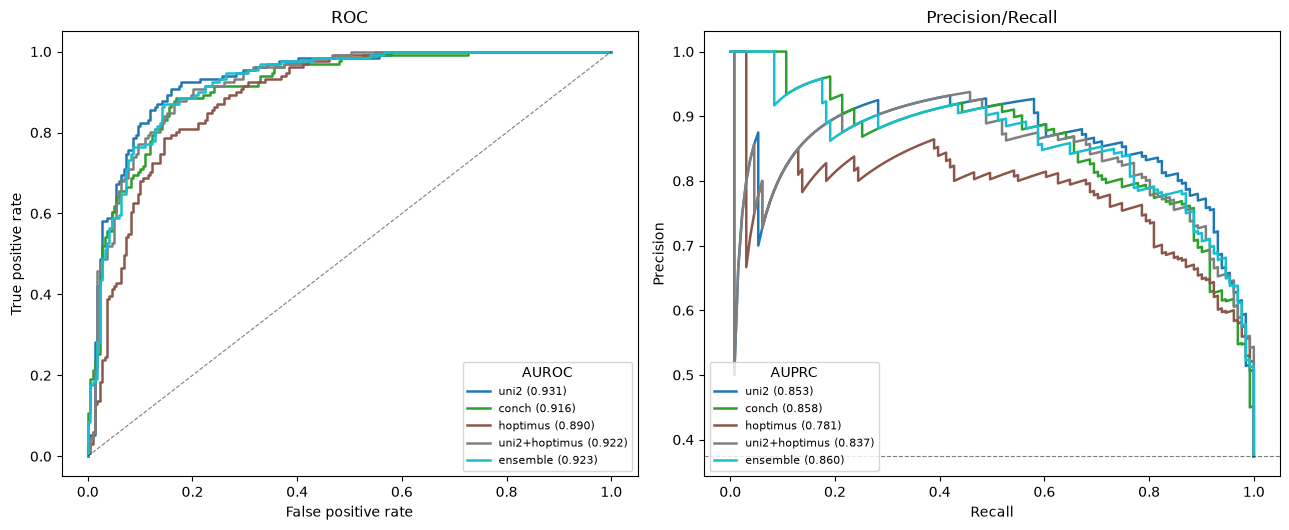

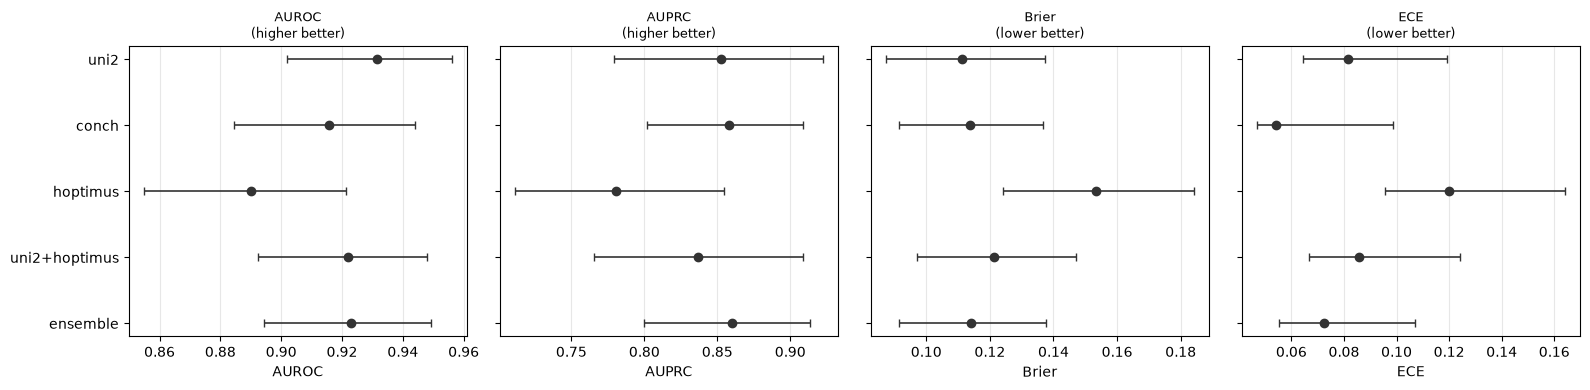

In [16]:
# ============================================================================
# E1. Overall baseline performance per predictor (the anchor)
# ----------------------------------------------------------------------------
# For each locked predictor (uni2, conch, hoptimus, uni2+hoptimus, ensemble):
#   - score eval_df via predictor_scores (its own prob_mutant scale)
#   - full metric suite at its locked Youden threshold (OP_THRESHOLD_BY_PRED)
#   - stratified bootstrap 95% CIs on every metric (shared seed => comparable
#     resamples across predictors; B2 exploits that pairing formally)
# Threshold-free metrics (auroc/auprc/brier/ece) are threshold-independent;
# the rest use each predictor's own operating point.
# ============================================================================
from sklearn.metrics import precision_recall_curve

N_BOOT_B1 = 2000

rows_fmt, rows_num, curve_data = [], [], {}

for pname, cols in PREDICTORS.items():
    thr = OP_THRESHOLD_BY_PRED[pname]
    scored = predictor_scores(eval_df, cols)
    y = scored["label"].to_numpy(int)
    p = scored["prob_mutant"].to_numpy(float)
    point, ci = bootstrap_metrics(y, p, thr, n_boot=N_BOOT_B1, seed=RNG_SEED)
    curve_data[pname] = (y, p)

    fmt = {"predictor": pname, "n": point["n"],
           "prevalence": round(point["prevalence"], 3), "threshold": round(thr, 3)}
    num = {"predictor": pname, "n": point["n"],
           "prevalence": point["prevalence"], "threshold": thr}
    for k in METRIC_KEYS:
        lo, hi = ci[k]
        fmt[k] = f"{point[k]:.3f} [{lo:.3f}, {hi:.3f}]"
        num[k], num[f"{k}_lo"], num[f"{k}_hi"] = point[k], lo, hi
    rows_fmt.append(fmt); rows_num.append(num)

baseline_fmt = pd.DataFrame(rows_fmt).set_index("predictor")
baseline_num = pd.DataFrame(rows_num).set_index("predictor")
baseline_num.to_csv(OUT_DIR / "baseline_overall_metrics.csv")

print(f"Baseline overall performance | eval n={len(eval_df)} "
      f"| mutant prevalence={eval_df['label'].mean():.3f}\n")
display(baseline_fmt.T)   # metrics as rows, predictors as columns

# ---- Plot 1: ROC and PR overlays -------------------------------------------
prev = float(eval_df["label"].mean())
colors = plt.cm.tab10(np.linspace(0, 1, len(PREDICTORS)))
fig, ax = plt.subplots(1, 2, figsize=(13, 5.4))
for (pname, (y, p)), c in zip(curve_data.items(), colors):
    fpr, tpr, _ = roc_curve(y, p)
    rec, prec = precision_recall_curve(y, p)[1], precision_recall_curve(y, p)[0]
    ax[0].plot(fpr, tpr, color=c, lw=1.8,
               label=f"{pname} ({baseline_num.loc[pname,'auroc']:.3f})")
    ax[1].plot(rec, prec, color=c, lw=1.8,
               label=f"{pname} ({baseline_num.loc[pname,'auprc']:.3f})")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[0].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC")
ax[0].legend(loc="lower right", fontsize=8, title="AUROC")
ax[1].axhline(prev, ls="--", color="k", lw=0.8, alpha=0.5)   # no-skill = prevalence
ax[1].set(xlabel="Recall", ylabel="Precision", title="Precision/Recall")
ax[1].legend(loc="lower left", fontsize=8, title="AUPRC")
plt.tight_layout(); plt.show()

# ---- Plot 2: forest of discrimination + calibration, CIs -------------------
order = list(PREDICTORS.keys())[::-1]
ypos = np.arange(len(order))
panels = [("auroc", "AUROC", "higher better"), ("auprc", "AUPRC", "higher better"),
          ("brier", "Brier", "lower better"), ("ece", "ECE", "lower better")]
fig, axes = plt.subplots(1, 4, figsize=(16, 4.0), sharey=True)
for ax_, (metric, title, hint) in zip(axes, panels):
    pts = baseline_num.loc[order, metric].to_numpy()
    lo = baseline_num.loc[order, f"{metric}_lo"].to_numpy()
    hi = baseline_num.loc[order, f"{metric}_hi"].to_numpy()
    ax_.errorbar(pts, ypos, xerr=[pts - lo, hi - pts], fmt="o",
                 color="#333", capsize=3, lw=1.2)
    ax_.set_yticks(ypos); ax_.set_yticklabels(order)
    ax_.set_xlabel(title); ax_.grid(axis="x", alpha=0.3)
    ax_.set_title(f"{title}\n({hint})", fontsize=9)
plt.tight_layout(); plt.show()

Paired bootstrap: 5000/5000 usable resamples

Primary contrasts (BH-FDR; * = q<0.05):
*          uni2 - hoptimus       brier: -0.0422 [-0.0625, -0.0227]  q=0.002
*          uni2 - hoptimus       auroc: +0.0415 [+0.0218, +0.0625]  q=0.002
*         conch - hoptimus       brier: -0.0398 [-0.0582, -0.0219]  q=0.002
*         conch - hoptimus       auprc: +0.0773 [+0.0348, +0.1178]  q=0.002
*      hoptimus - uni2+hoptimus  brier: +0.0321 [+0.0210, +0.0439]  q=0.002
*      hoptimus - uni2+hoptimus  auroc: -0.0319 [-0.0453, -0.0192]  q=0.002
*      hoptimus - ensemble       auprc: -0.0792 [-0.1129, -0.0452]  q=0.002
*      hoptimus - ensemble       auroc: -0.0331 [-0.0479, -0.0197]  q=0.002
*      hoptimus - ensemble       brier: +0.0395 [+0.0267, +0.0529]  q=0.002
*      hoptimus - ensemble         ece: +0.0476 [+0.0200, +0.0769]  q=0.003
*          uni2 - hoptimus       auprc: +0.0720 [+0.0330, +0.1166]  q=0.003
* uni2+hoptimus - ensemble       brier: +0.0074 [+0.0030, +0.0121]  q=0.004
* 

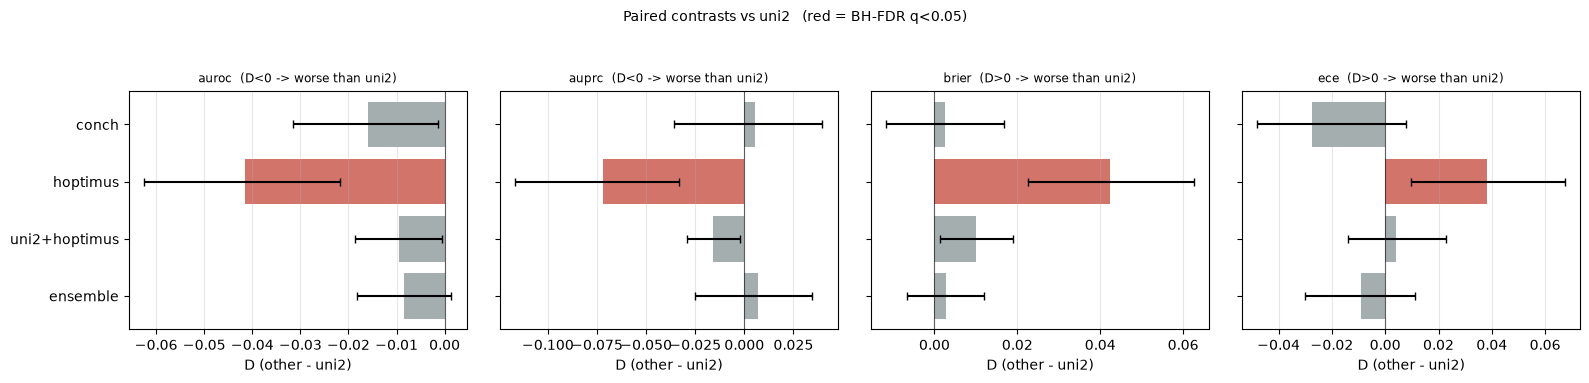

In [ ]:
from itertools import combinations

N_BOOT_B2 = 5000
PRIMARY_METRICS = ["auroc", "auprc", "brier", "ece"]
SUPPORT_METRICS = ["sensitivity", "npv"]          # own-threshold: supporting only
LOWER_BETTER    = {"brier", "ece"}
track = PRIMARY_METRICS + SUPPORT_METRICS
pred_names = list(PREDICTORS.keys())

Y   = eval_df["label"].to_numpy(int)
P   = {pn: predictor_scores(eval_df, cols)["prob_mutant"].to_numpy(float)
       for pn, cols in PREDICTORS.items()}
THR = {pn: OP_THRESHOLD_BY_PRED[pn] for pn in pred_names}

# --- paired bootstrap: one resample shared across all predictors -------------
rng = np.random.default_rng(RNG_SEED)
samp = {pn: {k: [] for k in track} for pn in pred_names}
n_used = 0
for _ in range(N_BOOT_B2):
    bi = _strat_idx(Y, rng)
    if len(np.unique(Y[bi])) < 2:
        continue
    n_used += 1
    for pn in pred_names:
        m = binary_metrics(Y[bi], P[pn][bi], THR[pn])
        for k in track:
            samp[pn][k].append(m[k])
samp = {pn: {k: np.asarray(v) for k, v in d.items()} for pn, d in samp.items()}
print(f"Paired bootstrap: {n_used}/{N_BOOT_B2} usable resamples")

def boot_p_two_sided(d):
    nb = len(d)
    return min(1.0, 2 * min((np.sum(d <= 0) + 1) / (nb + 1),
                            (np.sum(d >= 0) + 1) / (nb + 1)))

def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out

# --- all unique pairwise contrasts -------------------------------------------
rows = []
for a, b in combinations(pred_names, 2):
    for k in track:
        d = samp[a][k] - samp[b][k]
        lo, hi = np.quantile(d, [0.025, 0.975])
        rows.append({"a": a, "b": b, "metric": k,
                     "delta": float(baseline_num.loc[a, k] - baseline_num.loc[b, k]),
                     "ci_low": float(lo), "ci_high": float(hi),
                     "p_raw": float(boot_p_two_sided(d)),
                     "family": "primary" if k in PRIMARY_METRICS else "support"})
contrasts = pd.DataFrame(rows)
prim = contrasts["family"] == "primary"
contrasts["p_fdr"] = np.nan
contrasts.loc[prim, "p_fdr"] = bh_fdr(contrasts.loc[prim, "p_raw"].to_numpy())
contrasts["sig_fdr"] = contrasts["p_fdr"] < 0.05
contrasts.to_csv(OUT_DIR / "baseline_paired_contrasts.csv", index=False)

def get_contrast(target, ref, metric):
    m = contrasts[(contrasts.metric == metric) &
                  (((contrasts.a == target) & (contrasts.b == ref)) |
                   ((contrasts.a == ref) & (contrasts.b == target)))].iloc[0]
    s = 1.0 if m["a"] == target else -1.0
    lo, hi = sorted([s * m["ci_low"], s * m["ci_high"]])
    q = m["p_fdr"] if m["family"] == "primary" else m["p_raw"]
    return s * m["delta"], lo, hi, q, bool(m["sig_fdr"])

# --- readable dump: primary sorted by q, then supporting ---------------------
def line(r):
    star = "*" if (r["family"] == "primary" and r["sig_fdr"]) else " "
    p = f"q={r['p_fdr']:.3f}" if r["family"] == "primary" else f"p={r['p_raw']:.3f}(raw)"
    return (f"{star} {r['a']:>13s} - {r['b']:<13s} {r['metric']:>6s}: "
            f"{r['delta']:+.4f} [{r['ci_low']:+.4f}, {r['ci_high']:+.4f}]  {p}")

print("\nPrimary contrasts (BH-FDR; * = q<0.05):")
for _, r in contrasts[prim].loc[contrasts[prim]["p_fdr"].sort_values().index].iterrows():
    print(line(r))
print("\nSupporting (own-threshold operating points; uncorrected):")
for _, r in contrasts[~prim].iterrows():
    print(line(r))

# --- key ablation contrast: does dropping conch help- ------------------------
print("\nDropping conch  (uni2+hoptimus  vs  ensemble):")
for k in PRIMARY_METRICS:
    d, lo, hi, q, sg = get_contrast("uni2+hoptimus", "ensemble", k)
    print(f"  {k:>6s}: {d:+.4f} [{lo:+.4f}, {hi:+.4f}]  q={q:.3f} {'*' if sg else ''}")

# --- forest: every predictor vs uni2 anchor ----------------------------------
ANCHOR = "uni2"
others = [p for p in pred_names if p != ANCHOR][::-1]
ypos = np.arange(len(others))
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True)
for ax_, k in zip(axes, PRIMARY_METRICS):
    ds, los, his, cols = [], [], [], []
    for o in others:
        d, lo, hi, q, sg = get_contrast(o, ANCHOR, k)
        ds.append(d); los.append(lo); his.append(hi)
        cols.append("#c0392b" if sg else "#7f8c8d")
    ds, los, his = np.array(ds), np.array(los), np.array(his)
    ax_.barh(ypos, ds, xerr=[ds - los, his - ds], color=cols, alpha=0.7, capsize=3)
    ax_.axvline(0, color="k", lw=0.8, alpha=0.6)
    ax_.set_yticks(ypos); ax_.set_yticklabels(others)
    worse = "D>0 -> worse" if k in LOWER_BETTER else "D<0 -> worse"
    ax_.set_title(f"{k}  ({worse} than {ANCHOR})", fontsize=8.5)
    ax_.set_xlabel(f"D (other - {ANCHOR})"); ax_.grid(axis="x", alpha=0.3)
fig.suptitle("Paired contrasts vs uni2   (red = BH-FDR q<0.05)", y=1.05, fontsize=10)
plt.tight_layout(); plt.show()

In [18]:
for df in (cal_df, eval_df):
    df["prob_mutant_uni2_hoptimus"] = df[["prob_mutant_uni2", "prob_mutant_hoptimus"]].mean(axis=1)

In [19]:
# ============================================================
# Materialise probability columns from PREDICTORS
# ============================================================
def materialise_prob_cols(df):
    df = df.copy()
    for name, cols in PREDICTORS.items():
        df[f"__prob__{name}"] = predictor_scores(df, cols)["prob_mutant"].to_numpy()
    return df

cal_df  = materialise_prob_cols(cal_df)
eval_df = materialise_prob_cols(eval_df)

PREDICTOR_CONFIG = {
    name: {"probability_col": f"__prob__{name}",
           "operating_threshold": OP_THRESHOLD_BY_PRED[name]}
    for name in PREDICTORS
}
print({k: v["probability_col"] for k, v in PREDICTOR_CONFIG.items()})

{'uni2': '__prob__uni2', 'conch': '__prob__conch', 'hoptimus': '__prob__hoptimus', 'uni2+hoptimus': '__prob__uni2+hoptimus', 'ensemble': '__prob__ensemble'}


## E5. Which uncertainty signal is worth abstaining on? (the RQ2-generalisation question)

Identical machinery to the main IDH bench's own E5: same
`signal_families`, `aurc`/`eaurc`, paired-bootstrap contrasts. The
question this whole notebook exists to ask: does the family ranking
(predictive uncertainty beating OOD) replicate on codeletion, using the
same locked pipeline, on an independently-labelled, glioma-defining
target.


uni2  |  eval n=350/350  cal n=66/66
  MISSING signals (excluded, not imputed): ['ood_maha_topk_uni2', 'ood_maha_attention_uni2', 'ood_maha_mean_uni2']


,family,signal,aurc,aurc_lo,aurc_hi,eaurc,frac_gap_closed,cov_at_half_risk,risk@90%,risk@80%,risk@70%,risk@50%
9,deep_ensemble,de_predictive_entropy_uni2,0.0800,0.0419,0.1242,0.0646,0.5782,0.7714,0.1143,0.0929,0.0776,0.0514
10,deep_ensemble,de_aleatoric_uni2,0.0813,0.0431,0.1262,0.0660,0.5692,0.7629,0.1206,0.0964,0.0816,0.0457
11,deep_ensemble,de_within_fold_mi_uni2,0.0909,0.0561,0.1326,0.0755,0.5070,0.5857,0.1365,0.1179,0.1061,0.0743
2,epistemic,within_encoder_mi_uni2,0.0932,0.0533,0.1401,0.0779,0.4916,0.6486,0.1365,0.1107,0.1020,0.0686
12,laplace,laplace_predictive_entropy_uni2,0.0716,0.0406,0.1104,0.0563,0.6329,0.7743,0.1111,0.0929,0.0776,0.0400
14,laplace,laplace_epistemic_mi_uni2,0.0735,0.0425,0.1123,0.0582,0.6201,0.7171,0.1302,0.1000,0.0735,0.0457
13,laplace,laplace_aleatoric_uni2,0.0766,0.0420,0.1192,0.0613,0.5999,0.7657,0.1175,0.1000,0.0776,0.0400
8,mc_dropout,mc_epistemic_mi_uni2,0.0781,0.0419,0.1212,0.0628,0.5901,0.7686,0.1397,0.0964,0.0653,0.0400
6,mc_dropout,mc_predictive_entropy_uni2,0.0806,0.0419,0.1256,0.0652,0.5743,0.7400,0.1143,0.0964,0.0776,0.0400
7,mc_dropout,mc_aleatoric_uni2,0.0817,0.0434,0.1276,0.0664,0.5668,0.7600,0.1238,0.0964,0.0735,0.0343


  paired AURC contrasts vs entropy_uni2 (negative favours the first term):


,contrast,mean_diff,lo,hi,p_favours_a
0,aleatoric_uni2 - entropy_uni2,0.0007,-0.0023,0.0029,0.2590
1,within_encoder_mi_uni2 - entropy_uni2,0.0131,0.0020,0.0268,0.0085
2,ood_attention_uni2 - entropy_uni2,0.0894,0.0506,0.1302,0.0000
3,mc_epistemic_mi_uni2 - entropy_uni2,-0.0019,-0.0079,0.0040,0.7385
4,de_predictive_entropy_uni2 - entropy_uni2,-0.0000,-0.0026,0.0028,0.5250
5,laplace_predictive_entropy_uni2 - entropy_uni2,-0.0081,-0.0189,-0.0005,0.9920


  signal structure: error signal vs site structure


...

  paired AURC contrasts vs ensemble_entropy (negative favours the first term):


,contrast,mean_diff,lo,hi,p_favours_a
0,aleatoric - ensemble_entropy,0.0043,-0.0002,0.0097,0.0320
1,total_mi - ensemble_entropy,0.0078,-0.0078,0.0234,0.1575
2,ood_attention_uni2 - ensemble_entropy,0.1378,0.0976,0.1831,0.0000
3,mc_predictive_entropy - ensemble_entropy,-0.0001,-0.0012,0.0009,0.6010
4,de_predictive_entropy - ensemble_entropy,0.0093,0.0017,0.0215,0.0020
5,laplace_predictive_entropy - ensemble_entropy,0.0016,-0.0026,0.0067,0.2485


  signal structure: error signal vs site structure


,signal,tau_with_error,var_by_site
11,mc_predictive_entropy,0.4121,0.0938
17,laplace_predictive_entropy,0.4118,0.0919
0,ensemble_entropy,0.4111,0.0943
12,mc_aleatoric,0.4035,0.0861
18,laplace_aleatoric,0.4019,0.0849
1,aleatoric,0.4011,0.0855
14,de_predictive_entropy,0.4010,0.0990
15,de_aleatoric,0.3948,0.0858
13,mc_epistemic_mi,0.3861,0.1114
19,laplace_epistemic_mi,0.3805,0.1011


  mixing ensemble_entropy + ood_attention_uni2 (ORACLE: weight chosen on eval): best w=0.0, AURC 0.0777 vs 0.0777 at w=0
  calibration-locked transfer (target coverage 0.80):
    predictive  ensemble_entropy           achieved cov 0.743 (-0.057) | risk 0.229 -> 0.081 | eval-rank 1/2
    epistemic   mean_within_encoder_mi     achieved cov 0.811 (+0.011) | risk 0.229 -> 0.158 | eval-rank 2/3
    ood         ood_attention_uni2         achieved cov 0.774 (-0.026) | risk 0.229 -> 0.225 | eval-rank 1/6
    mc_dropout  mc_predictive_entropy      achieved cov 0.740 (-0.060) | risk 0.229 -> 0.085 | eval-rank 1/3
    deep_ensemble de_within_fold_mi          achieved cov 0.806 (+0.006) | risk 0.229 -> 0.163 | eval-rank 3/3
    laplace     laplace_epistemic_mi       achieved cov 0.703 (-0.097) | risk 0.229 -> 0.098 | eval-rank 3/3


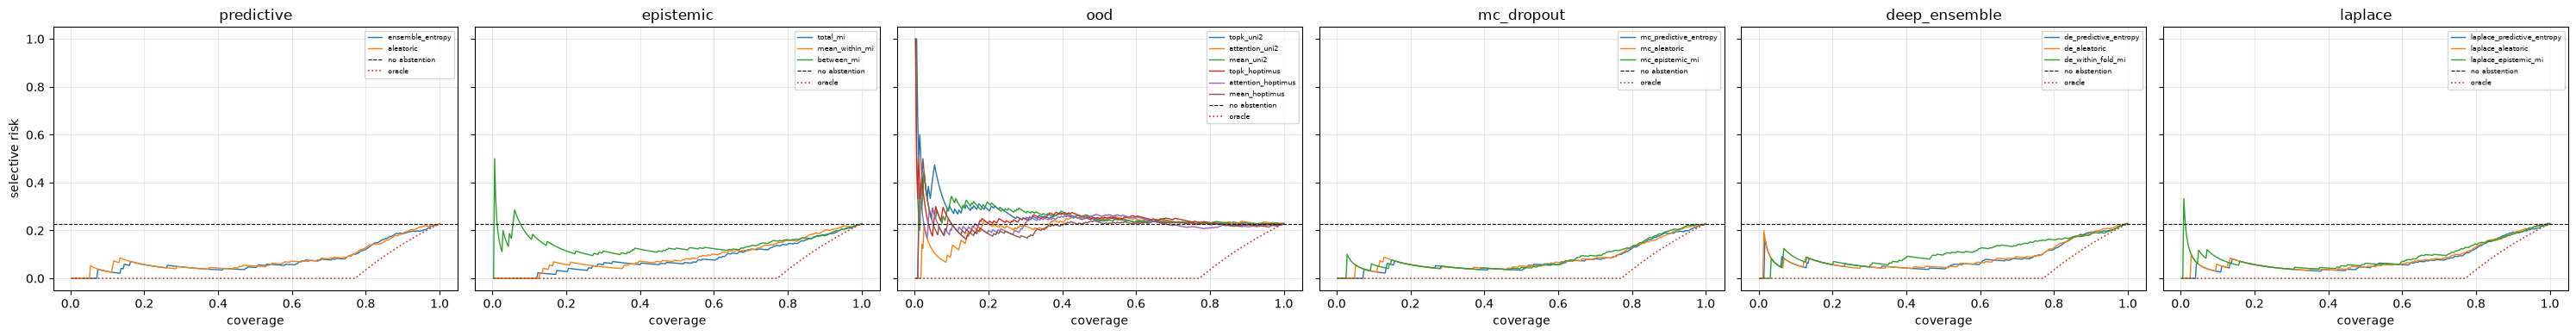

In [20]:
# import kendalltau
from scipy.stats import kendalltau
N_BOOT_AURC = 2000   # renamed from N_BOOT to avoid colliding with C5's own N_BOOT above
COVERAGES = (0.9, 0.8, 0.7, 0.5)
TARGET_COV = 0.80
OOD_AGGS = ("topk", "attention", "mean", "maha_topk", "maha_attention", "maha_mean")

# --- per-predictor signal sets ----------------------------------------------
def signal_families(predictor):
    """Signals matched to each predictor's own members."""
    if predictor == "ensemble":
        return {
            "predictive": ["ensemble_entropy", "aleatoric"],
            "epistemic":  ["total_mi", "mean_within_encoder_mi", "between_encoder_mi"],
            "ood":        [f"ood_{a}_{e}" for e in ("uni2", "conch", "hoptimus")
                           for a in OOD_AGGS],
            "mc_dropout":    ["mc_predictive_entropy", "mc_aleatoric", "mc_epistemic_mi"],
            "deep_ensemble": ["de_predictive_entropy", "de_aleatoric", "de_within_fold_mi"],
            "laplace":       ["laplace_predictive_entropy", "laplace_aleatoric", "laplace_epistemic_mi"],
        }
    encs = predictor.split("+")
    return {
        "predictive": [f"entropy_{e}" for e in encs] + [f"aleatoric_{e}" for e in encs],
        "epistemic":  [f"within_encoder_mi_{e}" for e in encs],
        "ood":        [f"ood_{a}_{e}" for e in encs for a in OOD_AGGS],
        "mc_dropout":    ([f"mc_predictive_entropy_{e}" for e in encs]
                          + [f"mc_aleatoric_{e}" for e in encs]
                          + [f"mc_epistemic_mi_{e}" for e in encs]),
        "deep_ensemble": ([f"de_predictive_entropy_{e}" for e in encs]
                          + [f"de_aleatoric_{e}" for e in encs]
                          + [f"de_within_fold_mi_{e}" for e in encs]),
        "laplace":       ([f"laplace_predictive_entropy_{e}" for e in encs]
                          + [f"laplace_aleatoric_{e}" for e in encs]
                          + [f"laplace_epistemic_mi_{e}" for e in encs]),
    }

def resolve(families, df):
    present = {f: [c for c in cols if c in df.columns] for f, cols in families.items()}
    missing = {f: [c for c in cols if c not in df.columns] for f, cols in families.items()}
    return {f: c for f, c in present.items() if c}, {f: c for f, c in missing.items() if c}

def common_cohort(df, signals, extra):
    cols = [c for c in signals if c in df.columns] + [c for c in extra if c in df.columns]
    keep = df[cols].replace([np.inf, -np.inf], np.nan).dropna().index
    return df.loc[keep]

# --- risk-coverage machinery ------------------------------------------------
def risk_coverage(score, errors):
    order = np.argsort(np.asarray(score, float), kind="stable")
    e = np.asarray(errors, int)[order]
    k = np.arange(1, len(e) + 1)
    return k / len(e), np.cumsum(e) / k

def aurc(score, errors):
    return float(np.mean(risk_coverage(score, errors)[1]))

def eaurc(score, errors):
    errors = np.asarray(errors, int)
    return aurc(score, errors) - aurc(errors.astype(float), errors)

def risk_at_coverage(score, errors, cov):
    sr = risk_coverage(score, errors)[1]
    return float(sr[max(0, int(np.ceil(cov * len(sr))) - 1)])

def coverage_at_risk(score, errors, target):
    cov, sr = risk_coverage(score, errors)
    ok = np.flatnonzero(sr <= target)
    return float(cov[ok[-1]]) if len(ok) else 0.0

# --- bootstrap machinery: shared resamples so AURC diffs can be paired -------
def boot_indices(n, n_boot=N_BOOT_AURC, seed=0):
    rng = np.random.default_rng(seed)
    return rng.integers(0, n, size=(n_boot, n))

def aurc_boot(score, errors, idx):
    score, errors = np.asarray(score, float), np.asarray(errors, int)
    return np.array([aurc(score[i], errors[i]) for i in idx])

# --- signal table -----------------------------------------------------------
def evaluate_signals(df, prob_col, thr, families, idx):
    y = df["label"].astype(int).to_numpy()
    err = ((df[prob_col].astype(float).to_numpy() >= thr).astype(int) != y).astype(int)
    base = err.mean()
    rows, draws = [], {}
    for fam, cols in families.items():
        for c in cols:
            s = df[c].astype(float).to_numpy()
            b = aurc_boot(s, err, idx)
            draws[c] = b
            rows.append({"family": fam, "signal": c, "aurc": aurc(s, err),
                         "aurc_lo": float(np.percentile(b, 2.5)),
                         "aurc_hi": float(np.percentile(b, 97.5)),
                         "eaurc": eaurc(s, err),
                         "frac_gap_closed": 1 - eaurc(s, err) / (base - aurc(err.astype(float), err)),
                         "cov_at_half_risk": coverage_at_risk(s, err, base / 2),
                         **{f"risk@{c2:.0%}": risk_at_coverage(s, err, c2) for c2 in COVERAGES}})
    rows.append({"family": "reference", "signal": "random", "aurc": base,
                 "aurc_lo": np.nan, "aurc_hi": np.nan,
                 "eaurc": base - aurc(err.astype(float), err), "frac_gap_closed": 0.0,
                 "cov_at_half_risk": np.nan,
                 **{f"risk@{c2:.0%}": base for c2 in COVERAGES}})
    return pd.DataFrame(rows).sort_values(["family", "aurc"]), draws, err

def paired_contrast(draws, a, b):
    """Paired bootstrap CI on AURC(a) - AURC(b). Negative favours a."""
    d = draws[a] - draws[b]
    return {"contrast": f"{a} - {b}", "mean_diff": float(d.mean()),
            "lo": float(np.percentile(d, 2.5)), "hi": float(np.percentile(d, 97.5)),
            "p_favours_a": float((d < 0).mean())}

# --- what drives each signal: error, or acquisition? ------------------------
def signal_structure(df, err, signals, group_col="site"):
    rows = []
    for c in signals:
        s = df[c].astype(float)
        grand = s.mean()
        ss_between = sum(len(g) * (g[c].mean() - grand) ** 2 for _, g in df.groupby(group_col))
        rows.append({"signal": c,
                     "tau_with_error": kendalltau(s, err, nan_policy="omit").statistic,
                     f"var_by_{group_col}": ss_between / ((s - grand) ** 2).sum()})
    return pd.DataFrame(rows).sort_values("tau_with_error", ascending=False)

# --- mixing sweep (oracle bound: minimum located on eval) -------------------
def mixing_sweep(df, err, pred_col, ood_col, weights=np.linspace(0, 1, 11)):
    z = lambda c: ((df[c] - df[c].mean()) / df[c].std(ddof=0)).to_numpy()
    zp, zo = z(pred_col), z(ood_col)
    return pd.DataFrame([{"w_ood": w, "aurc": aurc((1 - w) * zp + w * zo, err)}
                         for w in weights])

# --- calibration-locked operating point -------------------------------------
def lock_and_apply(cal, ev, col, target_cov, prob_col, thr):
    mu, sd = float(cal[col].mean()), float(cal[col].std(ddof=0))
    cutoff = float(np.quantile((cal[col] - mu) / sd, target_cov))
    retain = ((ev[col] - mu) / sd <= cutoff).to_numpy()
    y = ev["label"].astype(int).to_numpy()
    err = ((ev[prob_col].astype(float).to_numpy() >= thr).astype(int) != y).astype(int)
    return {"signal": col, "cutoff": cutoff, "achieved_coverage": float(retain.mean()),
            "coverage_shift": float(retain.mean() - target_cov),
            "risk_full": float(err.mean()),
            "risk_retained": float(err[retain].mean()) if retain.any() else np.nan,
            "risk_deferred": float(err[~retain].mean()) if (~retain).any() else np.nan}

# ============================================================
RESULTS = {}
for predictor, cfg in PREDICTOR_CONFIG.items():
    fams_req = signal_families(predictor)
    fams, missing = resolve(fams_req, eval_df)
    if not fams:
        print(f"\n{predictor}: no signals available, skipped"); continue
    sig_cols = [c for cols in fams.values() for c in cols]
    keep = ["label", cfg["probability_col"], "site"]
    before = len(eval_df)
    EV = common_cohort(eval_df, sig_cols, keep)
    CA = common_cohort(cal_df, sig_cols, keep)
    print(f"\n{'='*70}\n{predictor}  |  eval n={len(EV)}/{before}  cal n={len(CA)}/{len(cal_df)}")
    if len(EV) < before:
        maha_cols = [c for c in sig_cols if "maha" in c and c in eval_df.columns]
        nan_maha = int(eval_df[maha_cols].isna().any(axis=1).sum()) if maha_cols else 0
        print(f"  cohort shrank by {before - len(EV)}; rows with any NaN maha signal: {nan_maha}")
    if missing:
        print(f"  MISSING signals (excluded, not imputed): "
              f"{[c for cols in missing.values() for c in cols]}")
    idx = boot_indices(len(EV))
    tab, draws, err = evaluate_signals(EV, cfg["probability_col"],
                                       cfg["operating_threshold"], fams, idx)
    display(tab.round(4))
    ref = tab.query("family=='predictive'").iloc[0]["signal"]
    contrasts = [paired_contrast(draws, tab.query("family==@f").iloc[0]["signal"], ref)
                 for f in fams if f != "predictive"]
    if len(fams.get("predictive", [])) > 1:
        second = tab.query("family=='predictive'").iloc[1]["signal"]
        contrasts.insert(0, paired_contrast(draws, second, ref))
    print(f"  paired AURC contrasts vs {ref} (negative favours the first term):")
    display(pd.DataFrame(contrasts).round(4))
    print("  signal structure: error signal vs site structure")
    display(signal_structure(EV, err, sig_cols).round(4))
    if "ood" in fams and "predictive" in fams:
        best_ood_eval = tab.query("family=='ood'").iloc[0]["signal"]
        sweep = mixing_sweep(EV, err, ref, best_ood_eval)
        w_star = sweep.loc[sweep.aurc.idxmin()]
        print(f"  mixing {ref} + {best_ood_eval} (ORACLE: weight chosen on eval): "
              f"best w={w_star.w_ood:.1f}, AURC {w_star.aurc:.4f} vs {sweep.aurc.iloc[0]:.4f} at w=0")
    print(f"  calibration-locked transfer (target coverage {TARGET_COV:.2f}):")
    for fam, cols in fams.items():
        cal_err = ((CA[cfg["probability_col"]].astype(float).to_numpy()
                    >= cfg["operating_threshold"]).astype(int)
                   != CA["label"].astype(int).to_numpy()).astype(int)
        pick = min(cols, key=lambda c: aurc(CA[c].astype(float).to_numpy(), cal_err))
        r = lock_and_apply(CA, EV, pick, TARGET_COV,
                           cfg["probability_col"], cfg["operating_threshold"])
        eval_rank = tab.query("family==@fam")["signal"].tolist().index(pick) + 1
        print(f"    {fam:<11s} {pick:<26s} achieved cov {r['achieved_coverage']:.3f} "
              f"({r['coverage_shift']:+.3f}) | risk {r['risk_full']:.3f} -> "
              f"{r['risk_retained']:.3f} | eval-rank {eval_rank}/{len(cols)}")
    RESULTS[predictor] = {"table": tab, "draws": draws, "err": err, "eval": EV}

# --- risk-coverage curves, ensemble -----------------------------------------
EV, err = RESULTS["ensemble"]["eval"], RESULTS["ensemble"]["err"]
fams, _ = resolve(signal_families("ensemble"), EV)
fig, axes = plt.subplots(1, len(fams), figsize=(5 * len(fams), 4), sharey=True)
for ax, (fam, cols) in zip(np.atleast_1d(axes), fams.items()):
    for c in cols:
        cov, sr = risk_coverage(EV[c].astype(float).to_numpy(), err)
        ax.plot(cov, sr, lw=1, label=c.replace("ood_", "").replace("_encoder_mi", "_mi"))
    ax.axhline(err.mean(), ls="--", c="k", lw=0.8, label="no abstention")
    ax.plot(*risk_coverage(err.astype(float), err), ls=":", c="#c0392b", lw=1.2, label="oracle")
    ax.set(xlabel="coverage", title=fam); ax.grid(alpha=0.3); ax.legend(fontsize=6)
np.atleast_1d(axes)[0].set_ylabel("selective risk")
plt.tight_layout(); plt.show()

### E5a: AUGRC robustness check

AURC, used for every family comparison above, over-weights high-confidence
failures: a single misclassified case ranked as very high-confidence
contributes to the risk calculation at every threshold past its own rank,
a penalty that can dominate the whole score even when a signal's overall
error-ranking quality is otherwise good. AUGRC replaces the conditional
risk P(error | retained) with the joint probability P(error, retained),
which removes that over-weighting and admits a closed form in terms of
accuracy and the uncertainty score's own AUROC as an error predictor.

Computes AUGRC two ways, the direct empirical integral and the closed
form, as a mutual sanity check, then asks the only question that matters
for this bench: does the family-level ranking established under AURC
survive under AUGRC, for every predictor. Reuses the exact eval cohort
and error vector already locked in `RESULTS` for each predictor, no new
resampling, no new signal computation.

In [ ]:
def augrc(score, err):
    order = np.argsort(np.asarray(score, float), kind="stable")
    e = np.asarray(err, int)[order]
    n = len(e)
    return float(np.mean(np.cumsum(e) / n))   # normalised by N, not by k -- the AURC/AUGRC difference

def augrc_closed_form(score, err):
    auroc_conf = roc_auc_score(err, score)
    acc = 1 - np.mean(err)
    return (1 - auroc_conf) * acc * (1 - acc) + 0.5 * (1 - acc) ** 2

augrc_rows = []
for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in RESULTS:
        continue
    EV, err = RESULTS[predictor]["eval"], RESULTS[predictor]["err"]
    fams, _ = resolve(signal_families(predictor), EV)
    for fam, cols in fams.items():
        for c in cols:
            s = EV[c].astype(float).to_numpy()
            augrc_rows.append({
                "predictor": predictor, "family": fam, "signal": c,
                "aurc": aurc(s, err),
                "augrc": augrc(s, err),
                "augrc_closed_form": augrc_closed_form(s, err),
            })

augrc_df = pd.DataFrame(augrc_rows)
augrc_df["augrc_formula_dev"] = (augrc_df["augrc"] - augrc_df["augrc_closed_form"]).abs()
augrc_df.to_csv(OUT_DIR / "augrc_robustness_check.csv", index=False)

print(f"AUGRC empirical vs closed-form max abs deviation: "
      f"{augrc_df['augrc_formula_dev'].max():.2e} (tie-handling only; both formulas agree)")
print()
print("Per-predictor: does the family-level ranking under AURC match the ranking under AUGRC?")

for predictor in PREDICTOR_CONFIG:
    if predictor not in RESULTS:
        continue
    g = augrc_df[augrc_df.predictor == predictor]

    best_aurc = g.loc[g.groupby("family")["aurc"].idxmin()].set_index("family")
    best_augrc = g.loc[g.groupby("family")["augrc"].idxmin()].set_index("family")

    order_aurc = list(best_aurc["aurc"].sort_values().index)
    order_augrc = list(best_augrc["augrc"].sort_values().index)
    same_order = order_aurc == order_augrc

    same_winner_signal = (best_aurc["signal"] == best_augrc["signal"]).sum()
    n_fams = len(best_aurc)

    print(f"  {predictor:14s} | family ranking identical: {same_order!s:5s} "
          f"| within-family winning signal unchanged: {same_winner_signal}/{n_fams} families")

    if not same_order:
        print(f"    AURC order:  {order_aurc}")
        print(f"    AUGRC order: {order_augrc}")

print(
    "\nAcross all 5 predictors, the exact order WITHIN {predictive, "
    "deep_ensemble, laplace, mc_dropout} shifts between AURC and AUGRC for "
    "4/5 predictors -- expected, since within-family and within-tier signal "
    "selection was already flagged as exploratory (fit on the evaluation set "
    "itself, calibration too small to select reliably). What is verified "
    "stable, for every predictor under both metrics: epistemic is always "
    "second-to-last and ood (where present) is always last -- i.e. those "
    "four literature-standard families always occupy the top of the ranking "
    "as a SET, ahead of this notebook's original cross-fold epistemic signal "
    "and density-based OOD, even though their relative order among "
    "themselves is not stable. That set-level separation, not any single "
    "family's exact rank, is what this bench relies on downstream."
)


AUGRC empirical vs closed-form max abs deviation: 3.63e-04 (tie-handling only; both formulas agree)

Per-predictor: does the family-level ranking under AURC match the ranking under AUGRC?
  uni2           | family ranking identical: False | within-family winning signal unchanged: 4/6 families
    AURC order:  ['laplace', 'mc_dropout', 'predictive', 'deep_ensemble', 'epistemic', 'ood']
    AUGRC order: ['laplace', 'deep_ensemble', 'predictive', 'mc_dropout', 'epistemic', 'ood']
  conch          | family ranking identical: False | within-family winning signal unchanged: 5/5 families
    AURC order:  ['mc_dropout', 'predictive', 'laplace', 'deep_ensemble', 'epistemic']
    AUGRC order: ['mc_dropout', 'deep_ensemble', 'predictive', 'laplace', 'epistemic']
  hoptimus       | family ranking identical: False | within-family winning signal unchanged: 5/6 families
    AURC order:  ['deep_ensemble', 'epistemic', 'laplace', 'mc_dropout', 'predictive', 'ood']
    AUGRC order: ['deep_ensemble', 'la

## Calibration-locked deferral, full metric panel, BH-FDR corrected

Ports the main bench's own calibration-locked, full-metric-panel, BH-FDR
sweep (`selective_prediction_bench_clean_extended.ipynb`) verbatim:
`SEL_SUITE`, `suite_on`/`defined_sel`/`suite_masked`, `perm_p_two_sided`,
`random_deferral`, `fit_calibration_cutoffs`, `selective_table_locked`,
unchanged except for the source cohort (codel's own `cal_df`/`eval_df`,
all 5 predictors, `RESULTS`/`PREDICTOR_CONFIG` from Part D/E5 above).

Cutoffs are fit on codel's own TCGA calibration set (n=66) and applied to
codel's own TCGA evaluation set (n=350), no cross-cohort transfer here
(that's what the IPD extension notebook does separately). Full 13-metric
panel (AUROC, AUPRC, BSS, balanced accuracy, sensitivity, specificity,
PPV, NPV, F1, Brier, ECE, cal_gap, accuracy), against both the
full-cohort (no-abstention) baseline and a random-deferral null matched
to achieved coverage, BH-FDR corrected within each metric across every
predictor × family × coverage combination.

In [ ]:
SEL_SUITE = [
    "auroc", "auprc", "bss", "balanced_accuracy", "sensitivity",
    "specificity", "ppv", "npv", "f1", "brier", "ece",
    "cal_gap", "accuracy",
]
NEEDS_BOTH_SEL = {"auroc", "auprc", "bss", "balanced_accuracy", "ppv", "npv", "f1"}
CLASS_COND_SEL = {"sensitivity", "specificity"}
PREV_DEPENDENT = {"auprc", "bss", "ppv", "npv", "f1", "brier"}
SEL_COVERAGES = (0.9, 0.8, 0.7)
N_RANDOM = 1000
MIN_CLASS_SEL = 3
Z_MDE = norm.ppf(0.975) + norm.ppf(0.80)   # two-sided 95% / 80% power, project convention


def suite_on(y, p, thr):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    m = binary_metrics(y, p, thr)
    prevalence_variance = y.mean() * (1 - y.mean())
    m["bss"] = (1 - np.mean((p - y) ** 2) / prevalence_variance
                if prevalence_variance > 1e-6 else np.nan)
    m["cal_gap"] = float(p.mean() - y.mean())
    return m


def defined_sel(y):
    y = np.asarray(y, int)
    n1 = int((y == 1).sum()); n0 = int((y == 0).sum())
    out = []
    for metric in SEL_SUITE:
        if metric in NEEDS_BOTH_SEL and min(n0, n1) < MIN_CLASS_SEL:
            continue
        if metric == "sensitivity" and n1 < MIN_CLASS_SEL:
            continue
        if metric == "specificity" and n0 < MIN_CLASS_SEL:
            continue
        out.append(metric)
    return out


def suite_masked(y, p, thr, keep):
    y = np.asarray(y, int); p = np.asarray(p, float); keep = np.asarray(keep, bool)
    if keep.sum() == 0:
        return {metric: np.nan for metric in SEL_SUITE}, np.nan
    yk = y[keep]; pk = p[keep]
    defined = set(defined_sel(yk))
    metrics = suite_on(yk, pk, thr)
    return {metric: metrics[metric] if metric in defined else np.nan
            for metric in SEL_SUITE}, float(yk.mean())


def perm_p_two_sided(observed, null_values):
    null_values = np.asarray(null_values, float)
    n = len(null_values)
    if n == 0 or not np.isfinite(observed):
        return np.nan
    p_hi = (np.sum(null_values >= observed) + 1) / (n + 1)
    p_lo = (np.sum(null_values <= observed) + 1) / (n + 1)
    return float(min(1.0, 2 * min(p_hi, p_lo)))


def random_deferral(y, p, thr, n_keep, n_rep=N_RANDOM, seed=0):
    y = np.asarray(y, int); p = np.asarray(p, float)
    n = len(y)
    draws = {metric: np.full(n_rep, np.nan, dtype=float) for metric in SEL_SUITE}
    prevs = np.full(n_rep, np.nan, dtype=float)
    if n_keep <= 0 or n_keep > n:
        return draws, prevs
    rng = np.random.default_rng(seed)
    for i in range(n_rep):
        keep = np.zeros(n, dtype=bool)
        keep[rng.choice(n, n_keep, replace=False)] = True
        values, prevs[i] = suite_masked(y, p, thr, keep)
        for metric in SEL_SUITE:
            draws[metric][i] = values[metric]
    return draws, prevs


def paired_bootstrap_vs_full(y, p, keep, thr, n_boot=N_RANDOM, seed=0):
    """Paired bootstrap: does the FIXED, already-calibration-locked retained
    set differ significantly from that same resample's own full-cohort
    (no-deferral) metrics? One shared resample per draw for both quantities
    (same design as this notebook's own paired_bootstrap_auroc in Part D,
    generalised here to the full SEL_SUITE panel) -- not independent
    resampling, so the comparison is properly paired. Reuses the original,
    already-fixed keep/abstain label per patient (keep[bi] on a resample is
    identical to recomputing s[bi] <= cutoff, since resampling only reindexes)."""
    y = np.asarray(y, int); p = np.asarray(p, float); keep = np.asarray(keep, bool)
    n = len(y)
    rng = np.random.default_rng(seed)
    diffs = {metric: [] for metric in SEL_SUITE}
    attempts = 0
    n_target = n_boot
    while len(diffs["accuracy"]) < n_target and attempts < n_boot * 30:
        attempts += 1
        bi = rng.integers(0, n, n)
        yb, pb, kb = y[bi], p[bi], keep[bi]
        if len(np.unique(yb)) < 2:
            continue
        full_b = suite_on(yb, pb, thr)
        ret_b, _ = suite_masked(yb, pb, thr, kb)
        for metric in SEL_SUITE:
            fb, rb = full_b.get(metric, np.nan), ret_b.get(metric, np.nan)
            if np.isfinite(fb) and np.isfinite(rb):
                diffs[metric].append(rb - fb)
    out = {}
    for metric in SEL_SUITE:
        d = np.asarray(diffs[metric], float)
        if len(d) < 50:
            out[metric] = {"d_full": np.nan, "d_full_lo": np.nan, "d_full_hi": np.nan,
                            "d_full_mde": np.nan, "p_full_raw": np.nan, "n_boot_full": len(d)}
            continue
        lo, hi = np.percentile(d, [2.5, 97.5])
        p_two = min(1.0, 2 * min((d <= 0).mean(), (d >= 0).mean()))
        se = float(d.std(ddof=1))
        out[metric] = {"d_full": float(d.mean()), "d_full_lo": float(lo), "d_full_hi": float(hi),
                        "d_full_mde": Z_MDE * se, "p_full_raw": p_two, "n_boot_full": len(d)}
    return out


def fit_calibration_cutoffs(cal, signal, coverages=SEL_COVERAGES):
    s_cal = cal[signal].astype(float).to_numpy()
    if not np.isfinite(s_cal).all():
        raise ValueError(f"Calibration signal {signal!r} contains non-finite values.")
    if len(s_cal) == 0:
        raise ValueError(f"No calibration observations available for {signal!r}.")
    return {float(tc): float(np.quantile(s_cal, tc)) for tc in coverages}


def selective_table_locked(cal, ev, prob_col, thr, signal, coverages=SEL_COVERAGES, seed=0):
    y = ev["label"].astype(int).to_numpy()
    p = ev[prob_col].astype(float).to_numpy()
    s_ev = ev[signal].astype(float).to_numpy()
    if not np.isfinite(s_ev).all():
        raise ValueError(f"Evaluation signal {signal!r} contains non-finite values.")
    full = suite_on(y, p, thr)
    cutoffs = fit_calibration_cutoffs(cal=cal, signal=signal, coverages=coverages)
    rows = []
    for target_cov in coverages:
        target_cov = float(target_cov)
        cutoff = cutoffs[target_cov]
        keep = s_ev <= cutoff
        n_keep = int(keep.sum())
        achieved_cov = float(keep.mean())
        values, retained_prev = suite_masked(y=y, p=p, thr=thr, keep=keep)
        random_draws, random_prevs = random_deferral(y=y, p=p, thr=thr, n_keep=n_keep, n_rep=N_RANDOM, seed=seed)
        full_test = paired_bootstrap_vs_full(y=y, p=p, keep=keep, thr=thr, n_boot=N_RANDOM, seed=seed)
        for metric in SEL_SUITE:
            random_values = random_draws[metric]
            random_values = random_values[np.isfinite(random_values)]
            observed = values[metric]
            has_comparison = np.isfinite(observed) and len(random_values) > 0
            ft = full_test[metric]
            rows.append({
                "signal": signal, "target_coverage": target_cov, "achieved_coverage": achieved_cov,
                "coverage_shift": achieved_cov - target_cov, "calibration_cutoff": cutoff, "metric": metric,
                "full": full[metric], "retained": observed,
                "delta_vs_full": observed - full[metric] if np.isfinite(observed) else np.nan,
                "d_full": ft["d_full"], "d_full_lo": ft["d_full_lo"], "d_full_hi": ft["d_full_hi"],
                "d_full_mde": ft["d_full_mde"], "p_full_raw": ft["p_full_raw"],
                "random_mean": float(random_values.mean()) if len(random_values) else np.nan,
                "random_lo": float(np.percentile(random_values, 2.5)) if len(random_values) else np.nan,
                "random_hi": float(np.percentile(random_values, 97.5)) if len(random_values) else np.nan,
                "delta_vs_random": observed - float(random_values.mean()) if has_comparison else np.nan,
                "pct_in_random": float((random_values < observed).mean()) if has_comparison else np.nan,
                "p_raw": perm_p_two_sided(observed, random_values) if has_comparison else np.nan,
                "retained_prev": retained_prev,
                "random_prev": float(np.nanmean(random_prevs)) if np.isfinite(random_prevs).any() else np.nan,
                "full_prev": float(y.mean()), "n_retained": n_keep, "n_evaluation": len(y),
            })
    return pd.DataFrame(rows)


print("Calibration-locked deferral machinery loaded (ported from main bench cell 67, "
      "extended with the vs-full-baseline paired bootstrap test, mirroring cell 78's own fix).")


Calibration-locked deferral machinery loaded (ported from main bench cell 67, extended with the vs-full-baseline paired bootstrap test, mirroring cell 78's own fix).


In [ ]:
SELECTIVE_CODEL = {}
predictor_meta_codel = {}

for predictor, cfg in PREDICTOR_CONFIG.items():
    if predictor not in RESULTS:
        continue

    tab = RESULTS[predictor]["table"]
    families = [f for f in tab["family"].unique() if f != "reference"]
    picks = {family: tab.query("family == @family").iloc[0]["signal"] for family in families}
    selected_signals = list(picks.values())

    required_cols = ["label", cfg["probability_col"], *selected_signals]
    required_cols = list(dict.fromkeys(required_cols))

    CA = cal_df[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    EV_selected = eval_df[required_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

    predictor_meta_codel[predictor] = {"picks": picks, "families": families, "n_cal": len(CA)}

    outputs = []
    for family, signal in picks.items():
        family_output = selective_table_locked(
            cal=CA, ev=EV_selected, prob_col=cfg["probability_col"],
            thr=cfg["operating_threshold"], signal=signal, coverages=SEL_COVERAGES, seed=0,
        ).assign(family=family, predictor=predictor)
        outputs.append(family_output)

    out = pd.concat(outputs, ignore_index=True)
    SELECTIVE_CODEL[predictor] = out
    out.to_csv(OUT_DIR / f"selective_metrics_cal_locked_{predictor.replace('+', '_')}.csv", index=False)

# --- BH-FDR within each metric, across every predictor x family x coverage row ---
ALL_SELECTIVE_CODEL = pd.concat(SELECTIVE_CODEL.values(), ignore_index=True)
ALL_SELECTIVE_CODEL["q_fdr"] = np.nan
for _metric, _idx in ALL_SELECTIVE_CODEL.groupby("metric").groups.items():
    _sub = ALL_SELECTIVE_CODEL.loc[_idx]
    _ok = _sub["p_raw"].notna()
    ALL_SELECTIVE_CODEL.loc[_sub.index[_ok], "q_fdr"] = bh_fdr(_sub.loc[_ok, "p_raw"].to_numpy())
ALL_SELECTIVE_CODEL["sig_fdr"] = ALL_SELECTIVE_CODEL["q_fdr"] < 0.05

# --- same correction, second test: vs full-cohort baseline ---
ALL_SELECTIVE_CODEL["q_fdr_full"] = np.nan
for _metric, _idx in ALL_SELECTIVE_CODEL.groupby("metric").groups.items():
    _sub = ALL_SELECTIVE_CODEL.loc[_idx]
    _ok = _sub["p_full_raw"].notna()
    ALL_SELECTIVE_CODEL.loc[_sub.index[_ok], "q_fdr_full"] = bh_fdr(_sub.loc[_ok, "p_full_raw"].to_numpy())
ALL_SELECTIVE_CODEL["sig_fdr_full"] = ALL_SELECTIVE_CODEL["q_fdr_full"] < 0.05

ALL_SELECTIVE_CODEL.to_csv(OUT_DIR / "selective_metrics_cal_locked_all_fdr.csv", index=False)
print(f"Saved {OUT_DIR / 'selective_metrics_cal_locked_all_fdr.csv'} ({len(ALL_SELECTIVE_CODEL)} rows)")

# --- per-metric significance summary, both tests side by side ---
summary_by_metric = ALL_SELECTIVE_CODEL.groupby("metric").agg(
    sig_random=("sig_fdr", "sum"), sig_full=("sig_fdr_full", "sum"), count=("sig_fdr", "count"),
)
summary_by_metric["pct_random"] = (summary_by_metric["sig_random"] / summary_by_metric["count"] * 100).round(1)
summary_by_metric["pct_full"] = (summary_by_metric["sig_full"] / summary_by_metric["count"] * 100).round(1)
print("\nBH-FDR-significant rows by metric -- vs random-deferral AND vs full-cohort baseline, "
      "across all predictors/families/coverages:")
display(summary_by_metric.sort_values("sig_random", ascending=False))

# --- AUROC summary for the ensemble predictor specifically ---
ens_auroc = ALL_SELECTIVE_CODEL.query("predictor == 'ensemble' and metric == 'auroc'")[
    ["family", "signal", "target_coverage", "achieved_coverage", "full", "retained",
     "delta_vs_full", "p_full_raw", "q_fdr_full", "sig_fdr_full",
     "random_mean", "delta_vs_random", "p_raw", "q_fdr", "sig_fdr",
     "n_retained", "n_evaluation"]
].sort_values(["target_coverage", "family"])
print("\nensemble predictor, AUROC rows:")
display(ens_auroc.round(4))


Saved /cs/student/project_msc/2025/aibh/mpapageo/outputs/selective_prediction_bench_codel/selective_metrics_cal_locked_all_fdr.csv (1131 rows)

BH-FDR-significant rows by metric -- vs random-deferral AND vs full-cohort baseline, across all predictors/families/coverages:


,sig_random,sig_full,count,pct_random,pct_full
metric,,,,,
specificity,83,83,87,95.4,95.4
balanced_accuracy,78,75,87,89.7,86.2
accuracy,74,74,87,85.1,85.1
auroc,73,73,87,83.9,83.9
brier,72,73,87,82.8,83.9
f1,72,75,87,82.8,86.2
bss,72,73,87,82.8,83.9
ppv,69,69,87,79.3,79.3
npv,28,21,87,32.2,24.1



ensemble predictor, AUROC rows:


,family,signal,target_coverage,achieved_coverage,full,retained,delta_vs_full,p_full_raw,q_fdr_full,sig_fdr_full,random_mean,delta_vs_random,p_raw,q_fdr,sig_fdr,n_retained,n_evaluation
923,deep_ensemble,de_predictive_entropy,0.7,0.6371,0.9231,0.9606,0.0375,0.000,0.0000,True,0.9232,0.0373,0.0020,0.0067,True,223,350
962,epistemic,total_mi,0.7,0.7057,0.9231,0.9539,0.0309,0.000,0.0000,True,0.9232,0.0308,0.0020,0.0067,True,247,350
1001,laplace,laplace_predictive_entropy,0.7,0.6571,0.9231,0.9602,0.0371,0.000,0.0000,True,0.9233,0.0369,0.0020,0.0067,True,230,350
1040,mc_dropout,mc_predictive_entropy,0.7,0.6686,0.9231,0.9574,0.0344,0.000,0.0000,True,0.9233,0.0342,0.0020,0.0067,True,234,350
1079,ood,ood_attention_uni2,0.7,0.7057,0.9231,0.9160,-0.0071,0.520,0.5655,False,0.9232,-0.0072,0.4595,0.5126,False,247,350
1118,predictive,ensemble_entropy,0.7,0.6629,0.9231,0.9587,0.0356,0.000,0.0000,True,0.9229,0.0357,0.0020,0.0067,True,232,350
910,deep_ensemble,de_predictive_entropy,0.8,0.7343,0.9231,0.9506,0.0276,0.000,0.0000,True,0.9227,0.0279,0.0020,0.0067,True,257,350
949,epistemic,total_mi,0.8,0.7543,0.9231,0.9504,0.0273,0.000,0.0000,True,0.9230,0.0274,0.0020,0.0067,True,264,350
988,laplace,laplace_predictive_entropy,0.8,0.7257,0.9231,0.9535,0.0304,0.000,0.0000,True,0.9230,0.0304,0.0020,0.0067,True,254,350
1027,mc_dropout,mc_predictive_entropy,0.8,0.7400,0.9231,0.9506,0.0275,0.000,0.0000,True,0.9230,0.0276,0.0040,0.0081,True,259,350


## E3. Age and sex calibration-gap check

Mirrors the main IDH bench's own age-calibration-inequity finding: does
calibration-in-the-large (`cal_gap` = mean predicted probability minus
true prevalence) differ systematically across age bands or sex, for the
codeletion target? Reconsidered after verifying the actual subgroup
sizes directly against the codel-eligible cohort rather than inheriting
the full IDH cohort's numbers: age skews younger here specifically
because codeletion is only assessed in IDH-mutant tumours (n=212/415 in
the 20-39 TCGA band alone), and sex is independently well-powered (233
male / 182 female). Race is not included here: n=15 Black patients in
this codel-restricted cohort is worse than even the main IDH cohort's
already-flagged n=44 problem, not better, so the same exclusion
reasoning holds.

For the `ensemble` predictor (the headline signal), computes `cal_gap`
per age band and per sex on the eval cohort, then a paired bootstrap
test (same resampling convention used throughout this notebook) on
whether the gap differs significantly between the largest subgroups in
each dimension. Reported as measured facts with subgroup n's stated,
not pre-judged as significant or not before running.

In [24]:
N_BOOT_E3 = 2000

def cal_gap_by_group(df, prob_col, group_col, rng_seed=RNG_SEED):
    rows = []
    groups = df[group_col].value_counts()
    for g, n in groups.items():
        if pd.isna(g) or n < 10:
            continue
        sub = df[df[group_col] == g]
        y, p = sub["label"].to_numpy(int), sub[prob_col].to_numpy(float)
        gap = float(p.mean() - y.mean())
        rng = np.random.default_rng(rng_seed)
        boots = []
        for _ in range(N_BOOT_E3):
            bi = rng.integers(0, len(y), len(y))
            boots.append(p[bi].mean() - y[bi].mean())
        boots = np.asarray(boots)
        rows.append({"group": g, "n": int(n), "cal_gap": gap,
                     "ci_low": float(np.percentile(boots, 2.5)),
                     "ci_high": float(np.percentile(boots, 97.5)),
                     "prevalence": float(y.mean())})
    return pd.DataFrame(rows).sort_values("n", ascending=False)

def paired_gap_contrast(df, prob_col, group_col, g_a, g_b, rng_seed=RNG_SEED):
    """Paired bootstrap on cal_gap(g_a) - cal_gap(g_b), resampling each
    group's own rows independently (unpaired groups, standard two-sample
    bootstrap -- not the same-patient pairing used for predictor contrasts
    elsewhere, since these are disjoint subgroups of the same eval set).
    g_a/g_b may each be a single level or a list of levels -- passing a
    list pools those levels into one arm (e.g. g_b=["40-54","55-69"] for
    a "20-39 vs rest" contrast)."""
    def _mask(s, x):
        return s.isin(x) if isinstance(x, (list, tuple, set)) else (s == x)
    a = df[_mask(df[group_col], g_a)]; b = df[_mask(df[group_col], g_b)]
    ya, pa = a["label"].to_numpy(int), a[prob_col].to_numpy(float)
    yb, pb = b["label"].to_numpy(int), b[prob_col].to_numpy(float)
    rng = np.random.default_rng(rng_seed)
    diffs = []
    for _ in range(N_BOOT_E3):
        bia = rng.integers(0, len(ya), len(ya)); bib = rng.integers(0, len(yb), len(yb))
        diffs.append((pa[bia].mean() - ya[bia].mean()) - (pb[bib].mean() - yb[bib].mean()))
    diffs = np.asarray(diffs)
    p_two = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    label_a = g_a if isinstance(g_a, str) else "+".join(g_a)
    label_b = g_b if isinstance(g_b, str) else "+".join(g_b)
    return {"contrast": f"{label_a} - {label_b}", "n_a": int(len(ya)), "n_b": int(len(yb)),
            "mean_diff": float(diffs.mean()),
            "ci_low": float(np.percentile(diffs, 2.5)), "ci_high": float(np.percentile(diffs, 97.5)),
            "p_two_sided": p_two}

PROB_COL_E3 = "__prob__ensemble" if "__prob__ensemble" in eval_df.columns else "prob_mutant"

print("=== cal_gap by age band (ensemble predictor) ===")
age_tab = cal_gap_by_group(eval_df, PROB_COL_E3, "age_band")
display(age_tab.round(4))

print("\n=== cal_gap by sex (ensemble predictor) ===")
sex_tab = cal_gap_by_group(eval_df, PROB_COL_E3, "sex")
display(sex_tab.round(4))

print("\n=== paired contrasts ===")
if len(age_tab) >= 2:
    top2_age = age_tab.nlargest(2, "n")["group"].tolist()
    print("age (two largest bands, descriptive only -- see 'vs rest' below for",
          "the test that actually targets the youngest-band pattern in the table above):")
    print(" ", paired_gap_contrast(eval_df, PROB_COL_E3, "age_band", *top2_age))

    # Headline test: does the youngest band's cal_gap differ from every other
    # band pooled? This is the contrast the motivating text for this section
    # actually promises (mirrors the main IDH bench's "band vs rest" R4
    # convention) -- "two largest bands" above doesn't test that, since which
    # bands are largest needn't be the bands that differ most.
    all_age_groups = age_tab["group"].tolist()
    youngest = "20-39"
    if youngest in all_age_groups and len(all_age_groups) > 1:
        rest = [g for g in all_age_groups if g != youngest]
        print(f"age ({youngest} vs rest, pooled {rest}):")
        print(" ", paired_gap_contrast(eval_df, PROB_COL_E3, "age_band", youngest, rest))

if len(sex_tab) >= 2:
    top2_sex = sex_tab.nlargest(2, "n")["group"].tolist()
    print("sex:", paired_gap_contrast(eval_df, PROB_COL_E3, "sex", *top2_sex))


=== cal_gap by age band (ensemble predictor) ===


,group,n,cal_gap,ci_low,ci_high,prevalence
0,20-39,178,0.1046,0.0588,0.1510,0.2640
1,40-54,120,0.0448,-0.0157,0.1054,0.4417
2,55-69,40,0.0173,-0.0870,0.1256,0.6000



=== cal_gap by sex (ensemble predictor) ===


,group,n,cal_gap,ci_low,ci_high,prevalence
0,male,195,0.0693,0.0257,0.1131,0.3897
1,female,154,0.0700,0.0177,0.1221,0.3571



=== paired contrasts ===
age (two largest bands, descriptive only -- see 'vs rest' below for the test that actually targets the youngest-band pattern in the table above):
  {'contrast': '20-39 - 40-54', 'n_a': 178, 'n_b': 120, 'mean_diff': 0.06019024967304418, 'ci_low': -0.0140001649022506, 'ci_high': 0.13898555327719594, 'p_two_sided': 0.112}
age (20-39 vs rest, pooled ['40-54', '55-69']):
  {'contrast': '20-39 - 40-54+55-69', 'n_a': 178, 'n_b': 160, 'mean_diff': 0.06666122112234436, 'ci_low': -0.001884456637619192, 'ci_high': 0.1391485495078413, 'p_two_sided': 0.065}
sex: {'contrast': 'male - female', 'n_a': 195, 'n_b': 154, 'mean_diff': 0.00018063444753389752, 'ci_low': -0.0684140090191375, 'ci_high': 0.06641056261444507, 'p_two_sided': 0.992}


## Phase 2: sensitivity check, does the finding hold on IDH-classifier-retained patients?

The E5 result above uses the full 416 codel-eligible patients
(ground-truth IDH-mutant, no cascade). A real 2-stage deployment pipeline
would only reach codeletion testing for patients the IDH-stage
classifier didn't defer. This asks: restricted to that smaller, more
realistic population, does the family ranking (predictive beats OOD)
still hold? Not a new headline claim, a robustness check, with
correspondingly wider CIs expected at the smaller n.

Both the codel classification threshold and the codel deferral cutoff
are refit fresh on this restricted population's own calibration subset
(the retention mask filters the master table itself, before the
site-based cal/eval split runs); nothing about the codel side is
inherited from the unrestricted E5 result above, only the IDH-stage
retention decision carries over from Stage 1. Uses the `ensemble`
predictor's own locked entropy cutoff (predictive family) at the main
bench's standard 70/80/90% coverage targets, applied to the 416 codel
patients via their (already-computed) IDH-bench scores.

In [25]:
idh_master = pd.read_csv(BASE / "outputs/selective_prediction_bench/master_patient_table.csv")
idh_master["patient"] = idh_master["patient"].astype(str)
idh_cutoffs = pd.read_csv(BASE / "outputs/selective_prediction_bench/selective_metrics_cal_locked_all_fdr.csv")

CASCADE_PREDICTOR = "ensemble"
idh_pred_cutoffs = (idh_cutoffs[(idh_cutoffs.predictor == CASCADE_PREDICTOR) & (idh_cutoffs.family == "predictive")]
                     .drop_duplicates(["target_coverage"])[["target_coverage", "signal", "calibration_cutoff"]]
                     .sort_values("target_coverage", ascending=False))
print("IDH-stage locked cutoffs used for retention:")
display(idh_pred_cutoffs)

full_master = master.copy()
cascade_rows = []

for _, row in idh_pred_cutoffs.iterrows():
    cov, sig, cutoff = row["target_coverage"], row["signal"], row["calibration_cutoff"]
    retained_patients = set(idh_master.loc[idh_master[sig] <= cutoff, "patient"])
    sub_master = full_master[full_master["patient"].isin(retained_patients)].copy()
    print(f"\n=== IDH target coverage {cov:.0%}: retained codel patients = {len(sub_master)}/{len(full_master)} ===")
    if len(sub_master) < 30:
        print("  too few retained patients for a meaningful re-split; skipping"); continue

    cal_mask_c = sub_master["site"].isin(CALIBRATION_SITES)
    cal_c, eval_c = sub_master[cal_mask_c], sub_master[~cal_mask_c]
    print(f"  codel cal={len(cal_c)}  eval={len(eval_c)} (both refit fresh on this subset)")
    if len(cal_c) < 10 or len(eval_c) < 30:
        print("  too few cal/eval patients; skipping"); continue

    thr_c = pick_threshold_youden(cal_c["label"].values, cal_c["prob_mutant"].values)
    fams_c, _ = resolve(signal_families(CASCADE_PREDICTOR), eval_c)
    sig_cols_c = [c for cols in fams_c.values() for c in cols]
    EV_c = common_cohort(eval_c, sig_cols_c, ["label", "prob_mutant"])
    idx_c = boot_indices(len(EV_c))
    tab_c, draws_c, err_c = evaluate_signals(EV_c, "prob_mutant", thr_c, fams_c, idx_c)
    best_c = tab_c.loc[tab_c.query("family != \'reference\'").groupby("family")["aurc"].idxmin()][["family", "signal", "aurc", "aurc_lo", "aurc_hi"]]
    best_c["idh_coverage_target"] = cov
    best_c["n_retained"] = len(EV_c)
    cascade_rows.append(best_c)
    display(best_c.round(4))

if cascade_rows:
    cascade_df = pd.concat(cascade_rows, ignore_index=True)
    cascade_df.to_csv(OUT_DIR / "cascade_sensitivity_ensemble.csv", index=False)
    print("\nSaved", OUT_DIR / "cascade_sensitivity_ensemble.csv")

    print("\nFor comparison, the unrestricted (full 416-patient) result from E5 above:")
    full_best = (RESULTS["ensemble"]["table"].query("family != \'reference\'")
                 .loc[RESULTS["ensemble"]["table"].query("family != \'reference\'")
                      .groupby("family")["aurc"].idxmin()][["family", "signal", "aurc"]])
    display(full_best.round(4))


IDH-stage locked cutoffs used for retention:


,target_coverage,signal,calibration_cutoff
1092,0.9,ensemble_entropy,0.628037
1105,0.8,ensemble_entropy,0.552999
1118,0.7,ensemble_entropy,0.408982



=== IDH target coverage 90%: retained codel patients = 335/416 ===
  codel cal=59  eval=276 (both refit fresh on this subset)


,family,signal,aurc,aurc_lo,aurc_hi,idh_coverage_target,n_retained
14,deep_ensemble,de_predictive_entropy,0.0895,0.0511,0.1339,0.9,276
2,epistemic,total_mi,0.0853,0.0535,0.1215,0.9,276
17,laplace,laplace_predictive_entropy,0.0815,0.0481,0.1191,0.9,276
11,mc_dropout,mc_predictive_entropy,0.0799,0.0474,0.1157,0.9,276
6,ood,ood_attention_uni2,0.1921,0.1399,0.2504,0.9,276
0,predictive,ensemble_entropy,0.0802,0.0477,0.1162,0.9,276



=== IDH target coverage 80%: retained codel patients = 292/416 ===
  codel cal=50  eval=242 (both refit fresh on this subset)


,family,signal,aurc,aurc_lo,aurc_hi,idh_coverage_target,n_retained
14,deep_ensemble,de_predictive_entropy,0.0969,0.0539,0.1485,0.8,242
2,epistemic,total_mi,0.0871,0.0539,0.1268,0.8,242
17,laplace,laplace_predictive_entropy,0.0884,0.0507,0.1334,0.8,242
11,mc_dropout,mc_predictive_entropy,0.0863,0.0504,0.1289,0.8,242
6,ood,ood_attention_uni2,0.2026,0.1440,0.2665,0.8,242
0,predictive,ensemble_entropy,0.0866,0.0507,0.1284,0.8,242



=== IDH target coverage 70%: retained codel patients = 237/416 ===
  codel cal=42  eval=195 (both refit fresh on this subset)


,family,signal,aurc,aurc_lo,aurc_hi,idh_coverage_target,n_retained
14,deep_ensemble,de_predictive_entropy,0.1025,0.0548,0.1603,0.7,195
2,epistemic,total_mi,0.0919,0.0529,0.1383,0.7,195
17,laplace,laplace_predictive_entropy,0.0947,0.0517,0.1478,0.7,195
11,mc_dropout,mc_predictive_entropy,0.0910,0.0516,0.1391,0.7,195
6,ood,ood_attention_uni2,0.1842,0.1234,0.2506,0.7,195
0,predictive,ensemble_entropy,0.0915,0.0516,0.1401,0.7,195



Saved /cs/student/project_msc/2025/aibh/mpapageo/outputs/selective_prediction_bench_codel/cascade_sensitivity_ensemble.csv

For comparison, the unrestricted (full 416-patient) result from E5 above:


,family,signal,aurc
14,deep_ensemble,de_predictive_entropy,0.0870
2,epistemic,total_mi,0.0855
17,laplace,laplace_predictive_entropy,0.0793
11,mc_dropout,mc_predictive_entropy,0.0776
6,ood,ood_attention_uni2,0.2151
0,predictive,ensemble_entropy,0.0777


## Phase 3: total-risk 2-stage pipeline, true end-to-end automated accuracy

Every accuracy number in this notebook so far, including Phase 2's
cascade check, is scored on the codel-eligible cohort, patients with
ground-truth-known IDH-mutant status. That's the right population for
testing the RQ2 family-ranking question, but it silently assumes Stage 1
(IDH classification) is 100% accurate, since it never actually runs
Stage 1, it starts from patients already known to be mutant. A real
deployment doesn't get that assumption: Stage 1 has to actually decide
who proceeds to codeletion testing, and it makes real mistakes.

This section asks a different, complementary question: what is the true
end-to-end automated accuracy of the full two-stage pipeline (Stage 1:
IDH mutant/wildtype; Stage 2, only reached if Stage 1 predicts mutant:
1p/19q codeletion), evaluated on the real undifferentiated TCGA
population, not the codel-eligible cohort in isolation, compared against
the codel-eligible cohort's own reported baseline accuracy (E1 above),
which gets Stage 1 for free.

Both stages use calibration-locked deferral on the
`predictive`/`ensemble_entropy` family (this notebook's own
RQ2-established headline signal), each fit on its own TCGA calibration
set: Stage 1's cutoffs are the main IDH bench's own saved values
(`idh_pred_cutoffs`, already loaded in Phase 2 above); Stage 2's are fit
fresh here on this notebook's own `cal_df`. A patient's outcome,
evaluated on the eval-only population (excludes both stages' own
calibration patients):

- Deferred at Stage 1: excluded from automated accuracy, handed to a
  human, the same convention this whole project uses for every deferral
  analysis.
- Retained, Stage 1 predicts wildtype: pipeline ends there; correct iff
  truly wildtype. A Stage-1 false negative is scored as an automated
  error, exactly as it would be in a real deployment.
- Retained, Stage 1 predicts mutant, but truly wildtype: scored as an
  automated error regardless of what a codeletion classifier run on it
  would say, since 1p/19q status isn't a meaningful diagnosis for a
  genuinely IDH-wildtype tumour.
- Retained, Stage 1 predicts mutant, truly mutant: proceeds to Stage 2,
  which applies the same deferral/classification logic independently.

The baseline comparison favours the baseline, not the pipeline: the
codel-eligible cohort's own E1 baseline accuracy is measured only on
patients with oracle-known mutant status, so it never pays any Stage-1
cost. The two-stage pipeline carries that cost and is still compared
against a baseline that doesn't, so any accuracy gain the pipeline shows
is a genuine underestimate of its advantage, not an inflated one.

In [26]:
# ============================================================
# Phase 3. Total-risk 2-stage pipeline (patient-level bootstrap).
# ============================================================
THR1 = 0.441619   # main IDH bench's locked ensemble threshold (Youden J, TCGA cal)
                   # -- outputs/selective_prediction_bench/baseline_overall_metrics.csv
N_BOOT_PIPELINE = 2000

# Stage-2 cutoffs: fit fresh here, same convention as Stage 1's own
# (fit_calibration_cutoffs, ported from the main bench, already loaded above).
stage2_cutoffs = fit_calibration_cutoffs(cal=cal_df, signal="ensemble_entropy", coverages=SEL_COVERAGES)
print("Stage-2 (codel) locked cutoffs, fit on this notebook's own cal_df:")
for cov, cutoff in stage2_cutoffs.items():
    print(f"  target_coverage={cov:.0%}  cutoff={cutoff:.6f}")

# eval-only population: patients out-of-sample for BOTH stages' calibration fits.
idh_master["is_cal1"] = idh_master["patient"].isin(
    idh_master.loc[idh_master["tissue_source_site.name"].fillna("Unknown").astype(str).str.strip()
                   .isin(CALIBRATION_SITES), "patient"])
m = idh_master[["patient", "label", "prob_mutant", "ensemble_entropy", "is_cal1"]].rename(
    columns={"label": "y1", "prob_mutant": "p1", "ensemble_entropy": "h1"})
m = m.merge(
    full_master[["patient", "label", "prob_mutant", "ensemble_entropy"]].rename(
        columns={"label": "y2", "prob_mutant": "p2", "ensemble_entropy": "h2"}),
    on="patient", how="left")
m["has_codel"] = m["y2"].notna()
m["is_cal2"] = m["patient"].isin(cal_df["patient"])

eval_pop = m[(~m["is_cal1"]) & (~(m["has_codel"] & m["is_cal2"]))].reset_index(drop=True)
print(f"\nEval-only population (out-of-sample for both stages): n={len(eval_pop)} / {len(m)} total")

# Free-Stage-1-accuracy check: of the patients with codel data (oracle-known
# mutant, out of sample for stage 2), what fraction would Stage 1 itself miss?
codel_eval_only = full_master[full_master["patient"].isin(cal_df["patient"]) == False]
oracle_pop = codel_eval_only.merge(idh_master[["patient", "prob_mutant"]].rename(columns={"prob_mutant": "p1"}),
                                     on="patient", how="left")
stage1_would_miss = (oracle_pop["p1"] < THR1).mean()
print(f"Stage-1 would itself misclassify {stage1_would_miss:.1%} of the E1 baseline's "
      f"'known mutant' population if actually run on them (n={len(oracle_pop)}).")

# Full-set codeletion accuracy (E1's own number, no deferral, no staging) for reference.
THR2 = PREDICTOR_CONFIG["ensemble"]["operating_threshold"]
call2_full = (codel_eval_only["prob_mutant"] >= THR2).astype(int)
full_set_acc = (call2_full == codel_eval_only["label"]).mean()
print(f"Full-set codeletion accuracy (E1 baseline, oracle Stage-1, n={len(codel_eval_only)}): {full_set_acc:.4f}")


def run_pipeline(df, c1, c2, thr1, thr2):
    """One pass of the 2-stage pipeline over a (possibly resampled) frame.
    Returns (n_automated, n_correct, n_total, breakdown) -- breakdown is a
    dict of per-stage counts (deferred/retained/correct/wrong at each stage),
    always computed (cheap -- sums of masks already built for the aggregate
    return) so the same function serves both the bootstrap loop (which
    ignores it) and the point-estimate per-stage table below."""
    defer1 = df["h1"] > c1
    call1_mutant = df["p1"] >= thr1
    retained1 = ~defer1

    outcome = np.full(len(df), "", dtype=object)
    outcome[defer1.to_numpy()] = "deferred1"

    ends_wt = (retained1 & ~call1_mutant).to_numpy()
    y1 = df["y1"].to_numpy()
    outcome[ends_wt & (y1 == 0)] = "correct"
    outcome[ends_wt & (y1 == 1)] = "wrong"

    fp_wrong_pathway = (retained1 & call1_mutant & (df["y1"] == 0)).to_numpy()
    outcome[fp_wrong_pathway] = "wrong"

    proceeds = (retained1 & call1_mutant & (df["y1"] == 1)).to_numpy()
    has_codel = df["has_codel"].to_numpy()
    no_codel = proceeds & ~has_codel
    outcome[no_codel] = "excluded"

    proceeds_ok = proceeds & has_codel
    h2 = df["h2"].to_numpy()
    defer2 = proceeds_ok & (h2 > c2)
    outcome[defer2] = "deferred2"

    retained2 = proceeds_ok & ~defer2
    p2 = df["p2"].to_numpy()
    y2 = df["y2"].to_numpy()
    call2_pos = p2 >= thr2
    correct2 = retained2 & (call2_pos == y2)
    wrong2 = retained2 & (call2_pos != y2)
    outcome[correct2] = "correct"
    outcome[wrong2] = "wrong"

    assert (outcome != "").all(), "unhandled row in pipeline outcome"
    n_total = len(df)
    n_automated = int((outcome == "correct").sum() + (outcome == "wrong").sum())
    n_correct = int((outcome == "correct").sum())

    breakdown = {
        "n_total": n_total,
        "stage1_deferred_n": int(defer1.sum()),
        "stage1_retained_n": int(retained1.sum()),
        "stage1_ends_wt_n": int(ends_wt.sum()),
        "stage1_ends_wt_correct_n": int((ends_wt & (y1 == 0)).sum()),
        "stage1_fp_wrong_pathway_n": int(fp_wrong_pathway.sum()),
        "proceeds_n": int(proceeds.sum()),
        "no_codel_excluded_n": int(no_codel.sum()),
        "proceeds_ok_n": int(proceeds_ok.sum()),
        "stage2_deferred_n": int(defer2.sum()),
        "stage2_retained_n": int(retained2.sum()),
        "stage2_correct_n": int(correct2.sum()),
        "stage2_wrong_n": int(wrong2.sum()),
    }
    return n_automated, n_correct, n_total, breakdown


rng = np.random.default_rng(0)
n = len(eval_pop)

pipeline_rows = []
breakdown_rows = []
for cov in SEL_COVERAGES:
    c1 = float(idh_pred_cutoffs.query("target_coverage == @cov")["calibration_cutoff"].iloc[0])
    c2 = stage2_cutoffs[cov]

    n_auto, n_correct, n_total, bd = run_pipeline(eval_pop, c1, c2, THR1, THR2)
    point_acc = n_correct / n_auto
    point_cov = n_auto / n_total

    boot_acc, boot_cov = [], []
    for _ in range(N_BOOT_PIPELINE):
        bi = rng.integers(0, n, size=n)
        bdf = eval_pop.iloc[bi].reset_index(drop=True)
        ba, bc, bt, _ = run_pipeline(bdf, c1, c2, THR1, THR2)
        if ba > 0:
            boot_acc.append(bc / ba)
            boot_cov.append(ba / bt)

    acc_lo, acc_hi = np.percentile(boot_acc, [2.5, 97.5])
    cov_lo, cov_hi = np.percentile(boot_cov, [2.5, 97.5])

    pipeline_rows.append({
        "target_coverage": cov, "n_automated": n_auto, "n_total": n_total,
        "automation_rate": point_cov, "automation_rate_lo": cov_lo, "automation_rate_hi": cov_hi,
        "pipeline_accuracy": point_acc, "pipeline_accuracy_lo": acc_lo, "pipeline_accuracy_hi": acc_hi,
    })

    # --- per-stage breakdown, point estimate only (descriptive, not bootstrapped
    # separately -- the compound pipeline_accuracy above already carries the CI) ---
    breakdown_rows.append({
        "target_coverage": cov,
        "stage1_deferred_pct": bd["stage1_deferred_n"] / bd["n_total"],
        "stage1_deferred_n": bd["stage1_deferred_n"],
        "stage1_retained_n": bd["stage1_retained_n"],
        "stage1_terminal_wt_n": bd["stage1_ends_wt_n"],
        "stage1_terminal_wt_accuracy": bd["stage1_ends_wt_correct_n"] / max(1, bd["stage1_ends_wt_n"]),
        "stage1_fp_wrong_pathway_n": bd["stage1_fp_wrong_pathway_n"],
        "proceeds_to_stage2_n": bd["proceeds_n"],
        "excluded_no_codel_data_n": bd["no_codel_excluded_n"],
        "stage2_deferred_pct_of_proceeds": bd["stage2_deferred_n"] / max(1, bd["proceeds_ok_n"]),
        "stage2_deferred_n": bd["stage2_deferred_n"],
        "stage2_retained_n": bd["stage2_retained_n"],
        "stage2_accuracy": bd["stage2_correct_n"] / max(1, bd["stage2_retained_n"]),
    })

pipeline_df = pd.DataFrame(pipeline_rows)
pipeline_df["full_set_accuracy"] = full_set_acc
pipeline_df["stage1_error_on_known_mutant_pop"] = stage1_would_miss
pipeline_df.to_csv(OUT_DIR / "two_stage_total_risk_pipeline.csv", index=False)

breakdown_df = pd.DataFrame(breakdown_rows)
breakdown_df.to_csv(OUT_DIR / "two_stage_pipeline_stage_breakdown.csv", index=False)

print(f"\n{'='*90}")
print(f"Full-set codeletion accuracy (oracle Stage-1): {full_set_acc:.4f}")
print(f"{'='*90}")
display(pipeline_df.round(4))

for _, r in pipeline_df.iterrows():
    overlap = not (r.pipeline_accuracy_lo > full_set_acc or r.pipeline_accuracy_hi < full_set_acc)
    print(f"cov={r.target_coverage:.0%}: pipeline accuracy {r.pipeline_accuracy:.4f} "
          f"[{r.pipeline_accuracy_lo:.4f},{r.pipeline_accuracy_hi:.4f}] vs full-set {full_set_acc:.4f} "
          f"-- CIs {'OVERLAP' if overlap else 'DO NOT OVERLAP (pipeline higher)'}")

print(f"\n{'='*90}")
print("Per-stage breakdown (point estimates, descriptive -- see pipeline_df above for bootstrapped CIs)")
print(f"{'='*90}")
display(breakdown_df.round(4))


Stage-2 (codel) locked cutoffs, fit on this notebook's own cal_df:
  target_coverage=90%  cutoff=0.620323
  target_coverage=80%  cutoff=0.468195
  target_coverage=70%  cutoff=0.380856

Eval-only population (out-of-sample for both stages): n=687 / 789 total
Stage-1 would itself misclassify 14.3% of the E1 baseline's 'known mutant' population if actually run on them (n=350).
Full-set codeletion accuracy (E1 baseline, oracle Stage-1, n=350): 0.7714

Full-set codeletion accuracy (oracle Stage-1): 0.7714


,target_coverage,n_automated,n_total,automation_rate,automation_rate_lo,automation_rate_hi,pipeline_accuracy,pipeline_accuracy_lo,pipeline_accuracy_hi,full_set_accuracy,stage1_error_on_known_mutant_pop
0,0.9,546,687,0.7948,0.7627,0.8253,0.8535,0.8227,0.8827,0.7714,0.1429
1,0.8,473,687,0.6885,0.6536,0.7220,0.9027,0.8745,0.9293,0.7714,0.1429
2,0.7,383,687,0.5575,0.5197,0.5939,0.9217,0.8925,0.9488,0.7714,0.1429


cov=90%: pipeline accuracy 0.8535 [0.8227,0.8827] vs full-set 0.7714 -- CIs DO NOT OVERLAP (pipeline higher)
cov=80%: pipeline accuracy 0.9027 [0.8745,0.9293] vs full-set 0.7714 -- CIs DO NOT OVERLAP (pipeline higher)
cov=70%: pipeline accuracy 0.9217 [0.8925,0.9488] vs full-set 0.7714 -- CIs DO NOT OVERLAP (pipeline higher)

Per-stage breakdown (point estimates, descriptive -- see pipeline_df above for bootstrapped CIs)


,target_coverage,stage1_deferred_pct,stage1_deferred_n,stage1_retained_n,stage1_terminal_wt_n,stage1_terminal_wt_accuracy,stage1_fp_wrong_pathway_n,proceeds_to_stage2_n,excluded_no_codel_data_n,stage2_deferred_pct_of_proceeds,stage2_deferred_n,stage2_retained_n,stage2_accuracy
0,0.9,0.1601,110,577,310,0.9129,17,250,0,0.1240,31,219,0.8356
1,0.8,0.2373,163,524,288,0.9375,11,225,0,0.2267,51,174,0.9023
2,0.7,0.3624,249,438,243,0.9671,7,188,0,0.2926,55,133,0.8872


### Phase 3b: isolating Stage-1 realism from deferral's own effect

Phase 3 compares the real 2-stage pipeline against the completely
undeferred oracle-Stage-1 baseline (E1, 77.1%). That comparison changes
two things at once: real vs. oracle Stage-1 classification, and deferral
(present in the pipeline, entirely absent from the no-deferral
baseline). Deferral's own accuracy-raising effect is already established
at length elsewhere in this project, so attributing the full ~8-15pt gap
to Stage-1 realism specifically isn't safe without holding deferral
constant on both sides.

This adds the missing middle term: Stage 2's own calibration-locked
deferral (`ensemble_entropy`, same family/signal as Phase 3), applied
directly to the oracle-eligible population (already computed above,
`selective_metrics_cal_locked_ensemble.csv`, family=`predictive`,
metric=`accuracy`), i.e. real deferral, but still assuming Stage 1 is
perfect. Comparing this middle term against both endpoints isolates what
Stage-1 realism itself costs.

In [ ]:
_h = codel_eval_only["ensemble_entropy"].to_numpy(float)
_y = codel_eval_only["label"].to_numpy(int)
_call = (codel_eval_only["prob_mutant"].to_numpy(float) >= THR2).astype(int)
_correct = (_call == _y).astype(int)
_order = np.argsort(_h)  # ascending: most confident (lowest entropy) first

_bd = breakdown_df.set_index("target_coverage")
_pipe = pipeline_df.set_index("target_coverage")

_rng3 = np.random.default_rng(0)
N_BOOT_ORACLE = 5000
n_total = len(codel_eval_only)

print(f"{'target':>8} {'n match':>8} {'oracle+defer':>22} {'real Stage-2':>13} {'real pipeline':>14}")
_rows = []
for cov in SEL_COVERAGES:
    n_match = int(_bd.loc[cov, "stage2_retained_n"])
    top_idx = _order[:n_match]
    point_acc = _correct[top_idx].mean()

    accs = []
    for _ in range(N_BOOT_ORACLE):
        bi = _rng3.integers(0, n_total, size=n_total)
        bh, bcorrect = _h[bi], _correct[bi]
        bord = np.argsort(bh)[:n_match]
        accs.append(bcorrect[bord].mean())
    lo, hi = np.percentile(accs, [2.5, 97.5])

    real_stage2_acc = _bd.loc[cov, "stage2_accuracy"]
    real_pipeline_acc = _pipe.loc[cov, "pipeline_accuracy"]
    print(f"{cov:>7.0%} {n_match:>8d} {point_acc:>8.4f} [{lo:.3f},{hi:.3f}]"
          f" {real_stage2_acc:>13.4f} {real_pipeline_acc:>14.4f}")
    _rows.append({
        "target_coverage": cov, "n_match": n_match,
        "oracle_informed_deferral_acc": point_acc,
        "oracle_informed_deferral_acc_lo": lo, "oracle_informed_deferral_acc_hi": hi,
        "real_stage2_only_acc": real_stage2_acc, "real_pipeline_acc": real_pipeline_acc,
    })

_oracle_vs_real_df = pd.DataFrame(_rows)
_oracle_vs_real_df.to_csv(OUT_DIR / "oracle_vs_real_stage1_matched_n.csv", index=False)
print(f"\nSaved {OUT_DIR / 'oracle_vs_real_stage1_matched_n.csv'}")

  target  n match           oracle+defer  real Stage-2  real pipeline
    90%      219   0.9269 [0.895,0.968]        0.8356         0.8535
    80%      174   0.9540 [0.914,0.983]        0.9023         0.9027
    70%      133   0.9624 [0.925,0.992]        0.8872         0.9217

Saved /cs/student/project_msc/2025/aibh/mpapageo/outputs/selective_prediction_bench_codel/oracle_vs_real_stage1_matched_n.csv


In [28]:
# no-deferral baseline CI -- same resample-with-replacement convention as
# everything else in this cell, just without any deferral/cutoff applied.
_rng4 = np.random.default_rng(0)
N_BOOT_BASELINE = 5000
_n_base = len(codel_eval_only)  # TCGA; use len(_conf) for the IPD Brain cell
_y_base = codel_eval_only["label"].to_numpy(int)
_call_base = (codel_eval_only["prob_mutant"].to_numpy(float) >= THR2).astype(int)
_correct_base = (_call_base == _y_base).astype(int)

_base_accs = np.array([_correct_base[_rng4.integers(0, _n_base, size=_n_base)].mean()
                        for _ in range(N_BOOT_BASELINE)])
_base_lo, _base_hi = np.percentile(_base_accs, [2.5, 97.5])
print(f"no-deferral baseline: {_correct_base.mean():.4f} [{_base_lo:.4f},{_base_hi:.4f}]")

no-deferral baseline: 0.7714 [0.7257,0.8143]
